<a href="https://colab.research.google.com/github/ATOMScience-org/AMPL/blob/master/atomsci/ddm/examples/tutorials/07_EDA_With_Harmonization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory data analysis

In this notebook we will analyze molecular data and assay measurements for datasets collected from ChEMBL, Drug Target Commons (DTC) and Excape-DB.
1. ***COPY*** this notebook into your own google drive. Work and edit from that copy.
2. For this tutorial, we will use HTR3A target (https://www.ncbi.nlm.nih.gov/gene/3359) binding data from three different data sources, DTC, Excape-DB and ChEMBL. *If you want to use your own target, you can download your target related data from the following databases*:
  - https://www.ebi.ac.uk/chembl/
  - https://drugtargetcommons.fimm.fi/
  - https://solr.ideaconsult.net/search/excape/


# Scope of the tutorial:

*   Load the datasets
*   Clean and examine the data
*   Merge the datasets
*   Examine compound diversity
*   Create curated data 
*   Store the ML ready data (in Google Drive) for modeling

## Time on COLAB-Pro (~ 6 minutes)

## Mount your drive and decide on a **folder** in your drive where you can save the data. For example, we call the folder as **AMPL_EDA_07**

In [1]:
!date

Fri Sep 17 21:46:19 UTC 2021


## When you run the following cell, you will be asked to give permission for Google to mount your Google-drive. 

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**Install packages** 

In [ ]:
! pip install rdkit-pypi
! pip install deepchem

import deepchem
# print(deepchem.__version__)
! pip install umap
! pip install -U --ignore-installed numba
! pip install umap-learn
! pip install molvs
! pip install bravado

In [ ]:
import deepchem as dc

# get the Install AMPL_GPU_test.sh
!wget 'https://raw.githubusercontent.com/ATOMScience-org/AMPL/master/atomsci/ddm/examples/tutorials/config/install_AMPL_GPU_test.sh'
# run the script to install AMPL
! chmod u+x install_AMPL_GPU_test.sh
! ./install_AMPL_GPU_test.sh

# Load Libraries

In [5]:
# We temporarily disable warnings for demonstration.
# FutureWarnings and DeprecationWarnings are present from some of the AMPL 
# dependency modules.
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
# manipulate data
import pandas as pd

import json
import requests
import io
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib_venn as mpv
from scipy.stats import pearsonr

# set up visualization parameters
sns.set_context("paper")
sns.set_style("whitegrid")
sns.set_palette("Set2")
pal = sns.color_palette()
plt.rcParams['figure.figsize'] = [10,10]

pd.set_option('display.max_columns',(90))
pd.set_option('display.max_rows',(20))

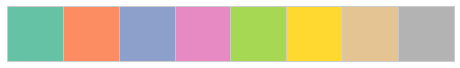

In [6]:
sns.palplot(pal)

In [7]:
# Import AMPL libraries
# 
import atomsci.ddm.utils.data_curation_functions as dcf
import atomsci.ddm.utils.curate_data as curate_data
import atomsci.ddm.pipeline.diversity_plots as dp
import atomsci.ddm.pipeline.chem_diversity as cd
# Additional python libraries
import pandas as pd
import numpy as np
import getpass, os

# Download/Load data

In [ ]:
! wget https://raw.githubusercontent.com/ATOMScience-org/AMPL/master/atomsci/ddm/examples/tutorials/datasets/HTR3A_DTC.csv
! wget https://raw.githubusercontent.com/ATOMScience-org/AMPL/master/atomsci/ddm/examples/tutorials/datasets/HTR3A_Excape.csv
! wget https://raw.githubusercontent.com/ATOMScience-org/AMPL/master/atomsci/ddm/examples/tutorials/datasets/HTR3A_ChEMBL.csv

# Explore and examine **data**

In [9]:
dtc = pd.read_csv("HTR3A_DTC.csv", sep=',', header=0 )
excape = pd.read_csv("HTR3A_Excape.csv", sep=',', header=0)
chembl = pd.read_csv("HTR3A_ChEMBL.csv", sep=',', header=0 )

In [10]:
dtc.iloc[1:3,1:10]

,Uniprot ID,Compound Name,Standard inchi key,Max Phase,Target Pref Name,Gene Names,Target Class,Wild type or mutant,Mutation information
1,P46098,NaN,SCDKHPSUXHBJDJ-UHFFFAOYSA-N,0,SEROTONIN 3A (5-HT3A) RECEPTOR,HTR3A,Ion channel,NaN,NaN
2,P46098,NaN,WGIPGQAPFNVWIX-XXFZXMJFSA-N,0,SEROTONIN 3A (5-HT3A) RECEPTOR,HTR3A,Ion channel,NaN,NaN


In [11]:
excape.iloc[1:3, 1:15]

,Original_Entry_ID,Entrez_ID,Activity_Flag,pXC50,DB,Original_Assay_ID,Tax_ID,Gene_Symbol,Ortholog_Group,SMILES
1,CHEMBL494999,79246,A,7.36000,chembl20,523350,10116,HTR3A,2102,N=1C=2C=CC=C(C)C2N3C(=CC=C3)C1N4CCN(CC4)C(C(=O...
2,44157937,79246,A,8.52288,pubchem,375321,10116,HTR3A,2102,OC(=NO)CN1CCN(CC1)C2=NC=3C(N4C2=CC=C4)=C(C=CC3)C


In [12]:
chembl.iloc[1:3, 1:10]

,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation
1,GLYCINE,4,75.07,0,-0.97,glycine,NCC(=O)O,EC50,NaN
2,NaN,0,312.37,0,0.88,9,O=C1c2cccc3[nH]c(=O)n(c23)CCN1[C@@H]1CN2CCC1CC2,Activity,'='


## **Examine and clean data** 
- What molecular (and other) identifiers exist for compounds from each database?
- What assay response types are there in each file?
- Think about how we might combine these data sources together

In [13]:
# get rid of spaces
chembl.columns = chembl.columns.str.replace(' ','_') 
dtc.columns = dtc.columns.str.replace(' ','_') 
excape.columns = excape.columns.str.replace(' ','_') 

print(chembl.shape)
print(dtc.shape)
print(excape.shape)

(1950, 45)
(1310, 43)
(649, 11)


### Questions to ask while exploring data

- what molecular (and other) identifiers exist for compounds from each database?
- what assay response types are there in each file?
- think about how we might combine these data sources together

## ChEMBL: Explore `dataset`

In [14]:
chembl.head()

,Molecule_ChEMBL_ID,Molecule_Name,Molecule_Max_Phase,Molecular_Weight,#RO5_Violations,AlogP,Compound_Key,Smiles,Standard_Type,Standard_Relation,Standard_Value,Standard_Units,pChEMBL_Value,Data_Validity_Comment,Comment,Uo_Units,Ligand_Efficiency_BEI,Ligand_Efficiency_LE,Ligand_Efficiency_LLE,Ligand_Efficiency_SEI,Potential_Duplicate,Assay_ChEMBL_ID,Assay_Description,Assay_Type,BAO_Format_ID,BAO_Label,Assay_Organism,Assay_Tissue_ChEMBL_ID,Assay_Tissue_Name,Assay_Cell_Type,Assay_Subcellular_Fraction,Assay_Parameters,Assay_Variant_Accession,Assay_Variant_Mutation,Target_ChEMBL_ID,Target_Name,Target_Organism,Target_Type,Document_ChEMBL_ID,Source_ID,Source_Description,Document_Journal,Document_Year,Cell_ChEMBL_ID,Properties
0,CHEMBL3233676,NaN,0,622.85,2,6.84,22a,CC1(C)C(=O)N(Cc2ccc(Cl)cc2Cl)C(=O)N1CCCCCN1CCN...,Inhibition,'=',13.75,%,NaN,NaN,NaN,UO_0000187,NaN,NaN,NaN,NaN,False,CHEMBL3240658,Reversible inhibition of human 5-HT3A expresse...,B,BAO_0000219,cell-based format,Homo sapiens,None,None,None,None,NaN,NaN,NaN,CHEMBL1899,Serotonin 3a (5-HT3a) receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL3232706,1,Scientific Literature,Eur. J. Med. Chem.,2014.0,None,NaN
1,CHEMBL773,GLYCINE,4,75.07,0,-0.97,glycine,NCC(=O)O,EC50,NaN,NaN,NaN,NaN,NaN,Not Determined,NaN,NaN,NaN,NaN,NaN,False,CHEMBL896288,Antagonist activity at human 5HT3A receptor ex...,F,BAO_0000219,cell-based format,Homo sapiens,None,None,HEK293,None,NaN,NaN,NaN,CHEMBL1899,Serotonin 3a (5-HT3a) receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL1148788,1,Scientific Literature,J. Med. Chem.,2007.0,CHEMBL3307715,NaN
2,CHEMBL3261486,NaN,0,312.37,0,0.88,9,O=C1c2cccc3[nH]c(=O)n(c23)CCN1[C@@H]1CN2CCC1CC2,Activity,'=',83.00,%,NaN,NaN,NaN,UO_0000187,NaN,NaN,NaN,NaN,False,CHEMBL3268498,Partial agonist activity at human 5-HT3A recep...,B,BAO_0000219,cell-based format,Homo sapiens,None,None,HEK293,None,NaN,NaN,NaN,CHEMBL1899,Serotonin 3a (5-HT3a) receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL3259590,1,Scientific Literature,Bioorg. Med. Chem. Lett.,2014.0,CHEMBL3307715,NaN
3,CHEMBL3943065,NaN,0,401.47,0,2.21,BDBM221658,CN1C2COCC1CC(NC(=O)c1cn(-c3cscn3)c3ncc(F)cc13)C2,IC50,'=',1.81,nM,8.74,NaN,388070,UO_0000065,21.78,0.43,6.53,12.1,False,CHEMBL3888296,In Vitro Inhibition of Ca Flux Assay: The 5HT3...,B,BAO_0000219,cell-based format,Homo sapiens,None,None,HEK-293T,None,NaN,NaN,NaN,CHEMBL1899,Serotonin 3a (5-HT3a) receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL3886642,37,BindingDB Database,NaN,2016.0,CHEMBL3706569,NaN
4,CHEMBL2086584,NaN,0,427.55,0,2.99,27,COc1ccc(-c2cc(NC(=O)C(C)CCCN3CCCN(C(C)=O)CC3)[...,IC50,'>',30000.00,nM,NaN,NaN,NaN,UO_0000065,NaN,NaN,NaN,NaN,False,CHEMBL2091623,Antagonist activity at human 5HT3A receptor ex...,F,BAO_0000219,cell-based format,Homo sapiens,None,None,HEK293,None,NaN,NaN,NaN,CHEMBL1899,Serotonin 3a (5-HT3a) receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL2086339,1,Scientific Literature,J. Med. Chem.,2012.0,CHEMBL3307715,NaN


In [15]:
chembl.Standard_Type.value_counts()

Ki                                                     611
IC50                                                   558
Inhibition                                             478
Activity                                               138
Ka                                                      46
EC50                                                    41
Vmax                                                    25
Kd                                                      22
% Ctrl                                                   8
% Inhibition of Control Specific Binding (Mean n=2)      8
Efficacy                                                 4
pKi                                                      4
pIC50                                                    3
Emax                                                     2
Selectivity ratio                                        1
Kb                                                       1
Name: Standard_Type, dtype: int64

## DTC: Explore dataset
Explore the loaded DTC and Excape dataframes, and answer the following questions:

- Number of data points in each file?
- Molecular identifiers from each file?
- Data types from each file?
- Data units in each file?
- What is the formula to translate IC50 to pIC50?
- What other information might be useful?

In [16]:
dtc.head(3)

,Compound_ID,Uniprot_ID,Compound_Name,Standard_inchi_key,Max_Phase,Target_Pref_Name,Gene_Names,Target_Class,Wild_type_or_mutant,Mutation_information,PubMed_ID,End_Point_Standard_Type,End_Point_Standard_Relation,End_Point_Standard_Value,End_Point_Standard_Units,Endpoint_Mode_of_Action,Assay_Format,Assay_Type,Assay_Sub_Type,Inhibitor_Type,Detection_Technology,Compound_concentration_value,Compound_concentration_value_units,Substrate_type,Substrate_Type_Standard_Relation,Substrate_Type_Standard_Value,Substrate_Type_Standard_Units,Assay_cell_line,Assay_Description,Activity_Comments,Title,Journal,Year,Volume,Issue,Authors,Annotation_Comments,Assay_ID,DTC_Tid,DTC_Activity_ID,DTC_Molregno,Record_ID,DTC_Document_ID
0,CHEMBL100086,P46098,NaN,OSVMSQACZRYAPT-UHFFFAOYSA-N,0,SEROTONIN 3A (5-HT3A) RECEPTOR,HTR3A,Ion channel,NaN,NaN,12482441.0,IC50,>,100000.0,NM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inhibitory concentration required against 5-HT...,NaN,Development of a presynaptic 5-HT1A antagonist.,Bioorg. Med. Chem. Lett.,2003.0,13.0,2.0,"Mattson RJ, Catt JD, Sloan CP, Gao Q, Carter R...",NaN,3062.0,DTCT0023221,1489397,DTCC00263953,917398,5847
1,CHEMBL104700,P46098,NaN,SCDKHPSUXHBJDJ-UHFFFAOYSA-N,0,SEROTONIN 3A (5-HT3A) RECEPTOR,HTR3A,Ion channel,NaN,NaN,22607684.0,KI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inhibition of 5-HT3 receptor,Not Determined,7-Azabicyclo[2.2.1]heptane as a scaffold for t...,Bioorg. Med. Chem. Lett.,2012.0,22.0,12.0,"Banister SD, Rendina LM, Kassiou M",NaN,820298.0,DTCT0023221,10478126,DTCC00272114,931177,48255
2,CHEMBL1079079,P46098,NaN,WGIPGQAPFNVWIX-XXFZXMJFSA-N,0,SEROTONIN 3A (5-HT3A) RECEPTOR,HTR3A,Ion channel,NaN,NaN,19767206.0,INHIBITION,<,50.0,%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Displacement of [3H]LY278584 from 5HT3 (recept...,NaN,Synthesis and in vitro autoradiographic evalua...,Bioorg. Med. Chem. Lett.,2009.0,19.0,21.0,"Donohue SR, Varnäs K, Jia Z, Gulyás B, Pike VW...",NaN,619795.0,DTCT0023221,3267809,DTCC00632772,857661,37697


In [17]:
dtc['End_Point_Standard_Type'].value_counts()

KI                   627
INHIBITION           258
IC50                 247
ACTIVITY             107
EC50                  28
VMAX                  25
KD                     4
EFFICACY               4
PKI                    4
PIC50                  3
EMAX                   1
KB                     1
SELECTIVITY RATIO      1
Name: End_Point_Standard_Type, dtype: int64

#### Assay data exploration

In [18]:
len(chembl.Assay_Description.unique()) 

347

Assay data responses questions
- What type of variable are the data responses?
- What kind of ML model would you build to predict this data?
- What kind of visualizations & analysis can you use to understand more about the data?

In [19]:
chembl.head(3)

,Molecule_ChEMBL_ID,Molecule_Name,Molecule_Max_Phase,Molecular_Weight,#RO5_Violations,AlogP,Compound_Key,Smiles,Standard_Type,Standard_Relation,Standard_Value,Standard_Units,pChEMBL_Value,Data_Validity_Comment,Comment,Uo_Units,Ligand_Efficiency_BEI,Ligand_Efficiency_LE,Ligand_Efficiency_LLE,Ligand_Efficiency_SEI,Potential_Duplicate,Assay_ChEMBL_ID,Assay_Description,Assay_Type,BAO_Format_ID,BAO_Label,Assay_Organism,Assay_Tissue_ChEMBL_ID,Assay_Tissue_Name,Assay_Cell_Type,Assay_Subcellular_Fraction,Assay_Parameters,Assay_Variant_Accession,Assay_Variant_Mutation,Target_ChEMBL_ID,Target_Name,Target_Organism,Target_Type,Document_ChEMBL_ID,Source_ID,Source_Description,Document_Journal,Document_Year,Cell_ChEMBL_ID,Properties
0,CHEMBL3233676,NaN,0,622.85,2,6.84,22a,CC1(C)C(=O)N(Cc2ccc(Cl)cc2Cl)C(=O)N1CCCCCN1CCN...,Inhibition,'=',13.75,%,NaN,NaN,NaN,UO_0000187,NaN,NaN,NaN,NaN,False,CHEMBL3240658,Reversible inhibition of human 5-HT3A expresse...,B,BAO_0000219,cell-based format,Homo sapiens,None,None,None,None,NaN,NaN,NaN,CHEMBL1899,Serotonin 3a (5-HT3a) receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL3232706,1,Scientific Literature,Eur. J. Med. Chem.,2014.0,None,NaN
1,CHEMBL773,GLYCINE,4,75.07,0,-0.97,glycine,NCC(=O)O,EC50,NaN,NaN,NaN,NaN,NaN,Not Determined,NaN,NaN,NaN,NaN,NaN,False,CHEMBL896288,Antagonist activity at human 5HT3A receptor ex...,F,BAO_0000219,cell-based format,Homo sapiens,None,None,HEK293,None,NaN,NaN,NaN,CHEMBL1899,Serotonin 3a (5-HT3a) receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL1148788,1,Scientific Literature,J. Med. Chem.,2007.0,CHEMBL3307715,NaN
2,CHEMBL3261486,NaN,0,312.37,0,0.88,9,O=C1c2cccc3[nH]c(=O)n(c23)CCN1[C@@H]1CN2CCC1CC2,Activity,'=',83.00,%,NaN,NaN,NaN,UO_0000187,NaN,NaN,NaN,NaN,False,CHEMBL3268498,Partial agonist activity at human 5-HT3A recep...,B,BAO_0000219,cell-based format,Homo sapiens,None,None,HEK293,None,NaN,NaN,NaN,CHEMBL1899,Serotonin 3a (5-HT3a) receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL3259590,1,Scientific Literature,Bioorg. Med. Chem. Lett.,2014.0,CHEMBL3307715,NaN


In [20]:
chembl.Standard_Units.unique()

array(['%', nan, 'nM', 'uM'], dtype=object)

## Excape-DB: Explore dataset

In [21]:
excape.columns

Index(['Ambit_InchiKey', 'Original_Entry_ID', 'Entrez_ID', 'Activity_Flag',
       'pXC50', 'DB', 'Original_Assay_ID', 'Tax_ID', 'Gene_Symbol',
       'Ortholog_Group', 'SMILES'],
      dtype='object')

In [22]:
excape.Activity_Flag.unique()

array(['A', 'N'], dtype=object)

In [23]:
excape['DB']

0      chembl20
1      chembl20
2       pubchem
3      chembl20
4      chembl20
         ...   
644     pubchem
645    chembl20
646     pubchem
647    chembl20
648    chembl20
Name: DB, Length: 649, dtype: object

In [24]:
excape.shape

(649, 11)

## **ChEMBL: Curation step** 
Change units to be the same for all responses

In [25]:
# change uM to nM units so they're all the same
chembl['Standard_Value_nM'] = np.where(chembl.Standard_Units == 'uM',
                                           chembl.Standard_Value * 1000,
                                           chembl.Standard_Value)

#### ChEMBL EDA
Summarize, describe, plot data for analysis

In [26]:
# summary statistics
chembl.describe()

,Molecule_Max_Phase,Standard_Value,pChEMBL_Value,Ligand_Efficiency_BEI,Source_ID,Document_Year,Standard_Value_nM
count,1950.000000,1.784000e+03,975.000000,810.000000,1950.000000,1801.000000,1.784000e+03
mean,0.286667,6.279166e+04,7.277262,22.023802,9.757436,2012.493615,6.299437e+04
std,0.984944,2.367589e+06,1.601719,6.780721,17.537913,4.327058,2.367584e+06
min,0.000000,-1.889000e+01,4.000000,4.500000,1.000000,1990.000000,-1.889000e+01
25%,0.000000,3.000000e+00,5.990000,18.225000,1.000000,2010.000000,3.097500e+00
50%,0.000000,5.000000e+01,7.500000,23.025000,1.000000,2013.000000,5.000000e+01
75%,0.000000,7.910825e+02,8.700000,25.970000,1.000000,2016.000000,1.089650e+03
max,4.000000,1.000000e+08,10.500000,49.740000,54.000000,2020.000000,1.000000e+08



Why do some columns seem numeric but not give mean, SD? Examine chembl csv file - answer is some 'None' entries

In [27]:
chembl=chembl.replace('None',np.nan)

In [28]:
# even after removing None you have to recast the column as numeric
numeric_cols=['Molecule_Max_Phase',
       'Molecular_Weight', '#RO5_Violations', 'AlogP', 'Standard_Value_nM',
       'pChEMBL_Value', 'Ligand_Efficiency_BEI', 'Ligand_Efficiency_LE',
       'Ligand_Efficiency_LLE', 'Ligand_Efficiency_SEI']
for col in numeric_cols:
  chembl[col]=chembl[col].astype(float)

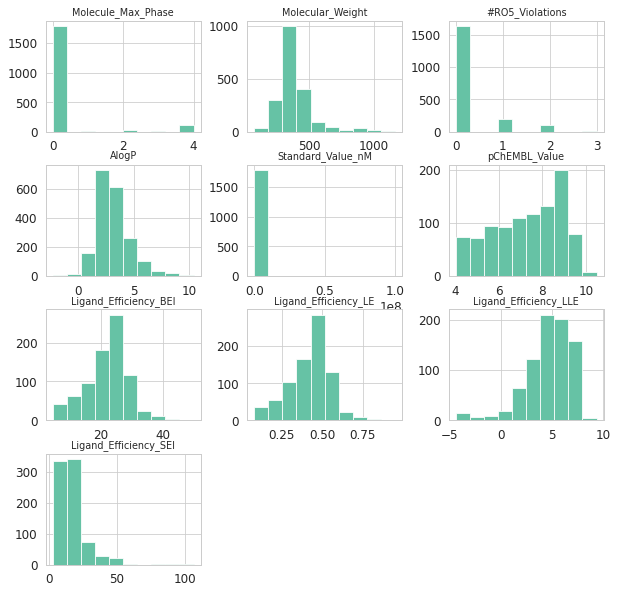

In [29]:
chembl[numeric_cols].hist(figsize=(10,10));

- **Note that pChembl value is better normalized than standard value**
- **Recall that there are lots of different activity types/assays represented in the value columns. Let's split those up:**

Standard_Type,% Ctrl,% Inhibition of Control Specific Binding (Mean n=2),Activity,EC50,Efficacy,Emax,IC50,Inhibition,Ka,Kb,Kd,Ki,Vmax
count,7.000000,8.000000,41.000000,24.000000,4.000000,2.000000,498.000000,418.000000,23.000000,1.0,4.000000,5.020000e+02,25.000000
mean,109.714286,-3.700000,260.273171,7554.570706,25.225000,54.500000,10069.385426,28.305755,7869.565217,0.3,3270.980750,2.076276e+05,94.480000
std,15.283044,4.452287,1559.327343,13061.147535,28.866402,55.861436,27059.164344,26.899361,2937.289224,NaN,6486.129538,4.463049e+06,17.535084
min,94.000000,-10.700000,-12.900000,1.100000,-0.100000,15.000000,0.090000,-18.890000,2200.000000,0.3,0.416000,0.000000e+00,34.500000
25%,99.000000,-6.350000,-0.500000,178.000000,5.225000,34.750000,1.720000,4.062500,5350.000000,0.3,0.484250,7.300000e+00,96.000000
50%,101.000000,-4.350000,2.000000,214.222222,18.500000,54.500000,80.350000,25.150000,10000.000000,0.3,41.753500,1.654800e+02,100.200000
75%,120.500000,0.350000,30.000000,10000.000000,38.500000,74.250000,5451.162500,50.000000,10000.000000,0.3,3312.250000,4.934302e+03,104.000000
max,134.000000,2.000000,10000.000000,50118.720000,64.000000,94.000000,257039.580000,100.000000,10000.000000,0.3,13000.000000,1.000000e+08,107.900000


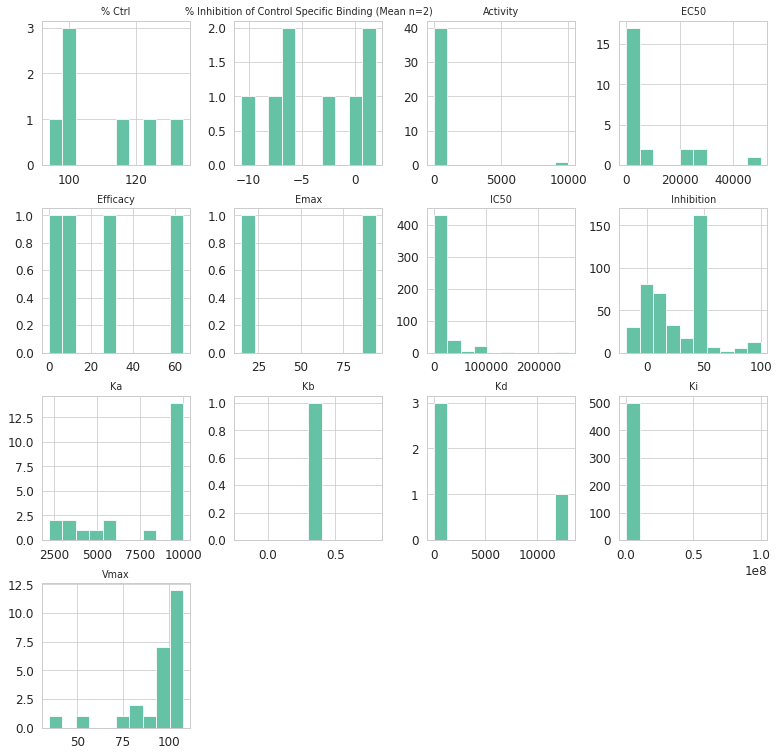

In [30]:
# examine standard values and pChembl values PER standard type
chembl_types=chembl.pivot_table(index = 'Molecule_ChEMBL_ID', columns = 'Standard_Type', values='Standard_Value_nM', aggfunc='mean')
display(chembl_types.describe())
chembl_types.hist(figsize=(13,13));

 What do you notice about the standard values?

Standard_Type,EC50,IC50,Kd,Ki
count,19.000000,408.000000,4.000000,405.000000
mean,6.684474,7.357423,7.681750,7.178580
std,1.152117,1.676965,2.153942,1.435567
min,4.580000,4.000000,4.890000,4.000000
25%,6.120000,5.792500,6.532500,6.150000
50%,6.750000,7.755000,8.205500,7.285000
75%,7.210000,8.900000,9.354750,8.330000
max,8.960000,10.050000,9.426000,10.500000


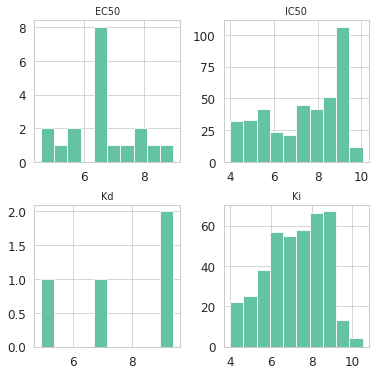

In [31]:
chembl_types=chembl.pivot_table(index = 'Molecule_ChEMBL_ID', columns = 'Standard_Type', values='pChEMBL_Value', aggfunc='mean')
display(chembl_types.describe())
chembl_types.hist(figsize=(6,6));

- **What do you notice about the pChEMBL values?**

## DTC: Curation Step
- Add pValue column from raw measurements if it doesn't exist

In [32]:
dtc.iloc[0:3, 0:5]

,Compound_ID,Uniprot_ID,Compound_Name,Standard_inchi_key,Max_Phase
0,CHEMBL100086,P46098,NaN,OSVMSQACZRYAPT-UHFFFAOYSA-N,0
1,CHEMBL104700,P46098,NaN,SCDKHPSUXHBJDJ-UHFFFAOYSA-N,0
2,CHEMBL1079079,P46098,NaN,WGIPGQAPFNVWIX-XXFZXMJFSA-N,0


## DTC EDA

In [33]:
dtc=dtc.replace('None', np.nan)


In [34]:
dtc.head(3)

,Compound_ID,Uniprot_ID,Compound_Name,Standard_inchi_key,Max_Phase,Target_Pref_Name,Gene_Names,Target_Class,Wild_type_or_mutant,Mutation_information,PubMed_ID,End_Point_Standard_Type,End_Point_Standard_Relation,End_Point_Standard_Value,End_Point_Standard_Units,Endpoint_Mode_of_Action,Assay_Format,Assay_Type,Assay_Sub_Type,Inhibitor_Type,Detection_Technology,Compound_concentration_value,Compound_concentration_value_units,Substrate_type,Substrate_Type_Standard_Relation,Substrate_Type_Standard_Value,Substrate_Type_Standard_Units,Assay_cell_line,Assay_Description,Activity_Comments,Title,Journal,Year,Volume,Issue,Authors,Annotation_Comments,Assay_ID,DTC_Tid,DTC_Activity_ID,DTC_Molregno,Record_ID,DTC_Document_ID
0,CHEMBL100086,P46098,NaN,OSVMSQACZRYAPT-UHFFFAOYSA-N,0,SEROTONIN 3A (5-HT3A) RECEPTOR,HTR3A,Ion channel,NaN,NaN,12482441.0,IC50,>,100000.0,NM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inhibitory concentration required against 5-HT...,NaN,Development of a presynaptic 5-HT1A antagonist.,Bioorg. Med. Chem. Lett.,2003.0,13.0,2.0,"Mattson RJ, Catt JD, Sloan CP, Gao Q, Carter R...",NaN,3062.0,DTCT0023221,1489397,DTCC00263953,917398,5847
1,CHEMBL104700,P46098,NaN,SCDKHPSUXHBJDJ-UHFFFAOYSA-N,0,SEROTONIN 3A (5-HT3A) RECEPTOR,HTR3A,Ion channel,NaN,NaN,22607684.0,KI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inhibition of 5-HT3 receptor,Not Determined,7-Azabicyclo[2.2.1]heptane as a scaffold for t...,Bioorg. Med. Chem. Lett.,2012.0,22.0,12.0,"Banister SD, Rendina LM, Kassiou M",NaN,820298.0,DTCT0023221,10478126,DTCC00272114,931177,48255
2,CHEMBL1079079,P46098,NaN,WGIPGQAPFNVWIX-XXFZXMJFSA-N,0,SEROTONIN 3A (5-HT3A) RECEPTOR,HTR3A,Ion channel,NaN,NaN,19767206.0,INHIBITION,<,50.0,%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Displacement of [3H]LY278584 from 5HT3 (recept...,NaN,Synthesis and in vitro autoradiographic evalua...,Bioorg. Med. Chem. Lett.,2009.0,19.0,21.0,"Donohue SR, Varnäs K, Jia Z, Gulyás B, Pike VW...",NaN,619795.0,DTCT0023221,3267809,DTCC00632772,857661,37697


In [35]:
dtc.End_Point_Standard_Units.unique() #already all nM

array(['NM', nan, '%'], dtype=object)

In [36]:
dtc.End_Point_Standard_Type.unique()

array(['IC50', 'KI', 'INHIBITION', 'ACTIVITY', 'EC50', 'KD', 'EMAX',
       'PKI', 'KB', 'VMAX', 'EFFICACY', 'PIC50', 'SELECTIVITY RATIO'],
      dtype=object)

In [37]:
dtc[dtc.End_Point_Standard_Units=='NM'].End_Point_Standard_Type.unique()

array(['IC50', 'KI', 'EC50', 'KD', 'ACTIVITY', 'KB'], dtype=object)

Curation step: create pValues from normal values

In [38]:
# add pX column
dtc['pDTC_Value'] = np.where(dtc.End_Point_Standard_Units == 'NM',
                             -np.log10(dtc.End_Point_Standard_Value/1000000000 ),
                             dtc.End_Point_Standard_Value)

In [39]:
dtc.describe()

,Max_Phase,Wild_type_or_mutant,Mutation_information,PubMed_ID,End_Point_Standard_Value,Endpoint_Mode_of_Action,Assay_Type,Assay_Sub_Type,Inhibitor_Type,Detection_Technology,Compound_concentration_value,Compound_concentration_value_units,Substrate_type,Substrate_Type_Standard_Relation,Substrate_Type_Standard_Value,Substrate_Type_Standard_Units,Year,Volume,Issue,Annotation_Comments,Assay_ID,DTC_Activity_ID,Record_ID,DTC_Document_ID,pDTC_Value
count,1310.000000,0.0,0.0,1.221000e+03,1.184000e+03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1191.000000,1129.000000,1099.000000,0.0,1.191000e+03,1.310000e+03,1.310000e+03,1310.000000,1184.000000
mean,0.273282,NaN,NaN,2.021775e+07,9.446193e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.376154,40.450841,64.520473,NaN,8.044485e+05,8.014779e+06,1.134441e+06,46053.261832,14.965198
std,0.959917,NaN,NaN,4.378655e+06,2.906114e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.739353,38.635750,597.044181,NaN,3.527907e+05,5.025834e+06,6.368512e+05,14973.468734,21.453868
min,0.000000,NaN,NaN,1.652026e+06,-1.700000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1990.000000,3.000000,1.000000,NaN,3.062000e+03,1.667600e+04,6.984000e+03,1553.000000,-17.000000
25%,0.000000,NaN,NaN,1.920847e+07,1.336750e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009.000000,21.000000,8.000000,NaN,5.784460e+05,2.887680e+06,6.209980e+05,36218.000000,5.000000
50%,0.000000,NaN,NaN,2.114699e+07,7.580000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011.000000,44.000000,14.000000,NaN,8.009190e+05,7.649972e+06,1.127832e+06,48204.000000,7.000000
75%,0.000000,NaN,NaN,2.295924e+07,3.750000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012.000000,54.000000,19.000000,NaN,9.321840e+05,1.258471e+07,1.685393e+06,55935.000000,8.968955
max,4.000000,NaN,NaN,2.813524e+07,1.000000e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,450.000000,7169.000000,NaN,1.586709e+06,1.476012e+07,2.111536e+06,69827.000000,107.900000


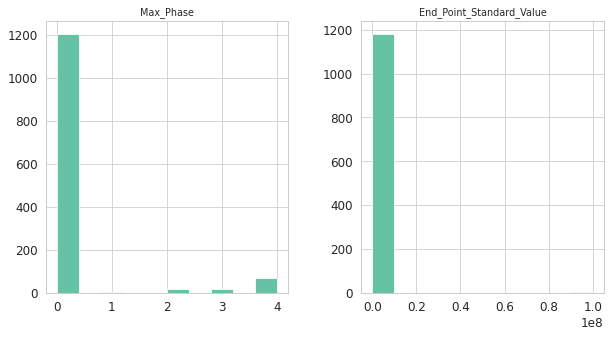

In [40]:
numeric_cols=['Max_Phase', 'End_Point_Standard_Value']
dtc[numeric_cols].hist(figsize=(10,5));

End_Point_Standard_Type,ACTIVITY,EC50,EFFICACY,EMAX,IC50,INHIBITION,KB,KD,KI,VMAX
count,26.000000,19.000000,4.000000,1.0,194.000000,232.000000,1.0,4.000000,4.900000e+02,25.000000
mean,411.119231,4869.599605,25.225000,15.0,18830.922569,34.748922,0.3,3270.962500,2.126429e+05,94.480000
std,1955.960159,12577.519415,28.866402,NaN,34557.858497,26.254918,NaN,6486.141808,4.517362e+06,17.535084
min,-7.000000,1.100000,-0.100000,15.0,0.090000,-17.000000,0.3,0.320000,3.160000e-02,34.500000
25%,-0.250000,101.000000,5.225000,15.0,100.000000,10.300000,0.3,0.477500,7.522500e+00,96.000000
50%,28.000000,178.000000,18.500000,15.0,2602.972500,50.000000,0.3,41.765000,1.945000e+02,100.200000
75%,50.000000,1210.000000,38.500000,15.0,30000.000000,50.000000,0.3,3312.250000,4.421250e+03,104.000000
max,10000.000000,50118.720000,64.000000,15.0,251188.640000,100.000000,0.3,13000.000000,1.000000e+08,107.900000


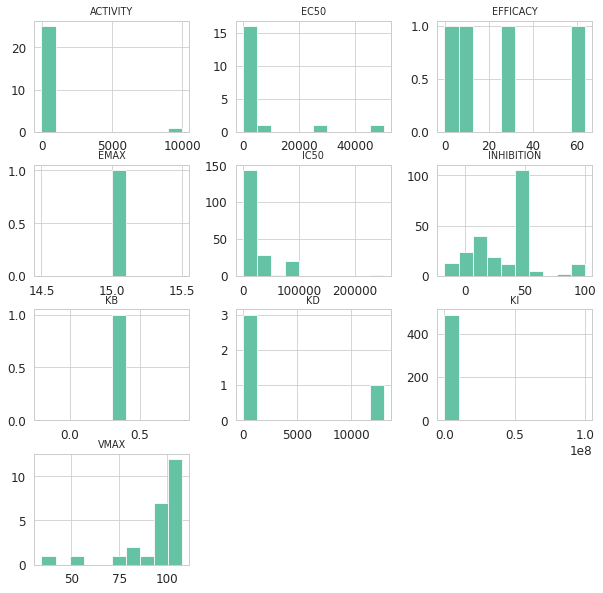

In [41]:
dtc_types=dtc.pivot_table(index = 'Compound_ID', columns = 'End_Point_Standard_Type', values='End_Point_Standard_Value', aggfunc='mean')
display(dtc_types.describe())
dtc_types.hist(figsize=(10,10));

End_Point_Standard_Type,ACTIVITY,EC50,EFFICACY,EMAX,IC50,INHIBITION,KB,KD,KI,VMAX
count,26.000000,19.000000,4.000000,1.0,194.000000,232.000000,1.000000,4.000000,490.000000,25.000000
mean,26.696154,6.630151,25.225000,15.0,5.787025,34.748922,9.522879,7.684388,6.788864,94.480000
std,28.630997,1.211224,28.866402,NaN,1.295001,26.254918,NaN,2.160629,1.555564,17.535084
min,-7.000000,4.300000,-0.100000,15.0,3.600000,-17.000000,9.522879,4.886057,1.000000,34.500000
25%,-0.250000,6.086315,5.225000,15.0,4.522879,10.300000,9.522879,6.532206,5.402234,96.000000
50%,23.500000,6.749580,18.500000,15.0,5.601545,50.000000,9.522879,8.178323,6.811128,100.200000
75%,50.000000,7.184684,38.500000,15.0,7.000000,50.000000,9.522879,9.330506,8.136677,104.000000
max,87.000000,8.958607,64.000000,15.0,10.045757,100.000000,9.522879,9.494850,10.500313,107.900000


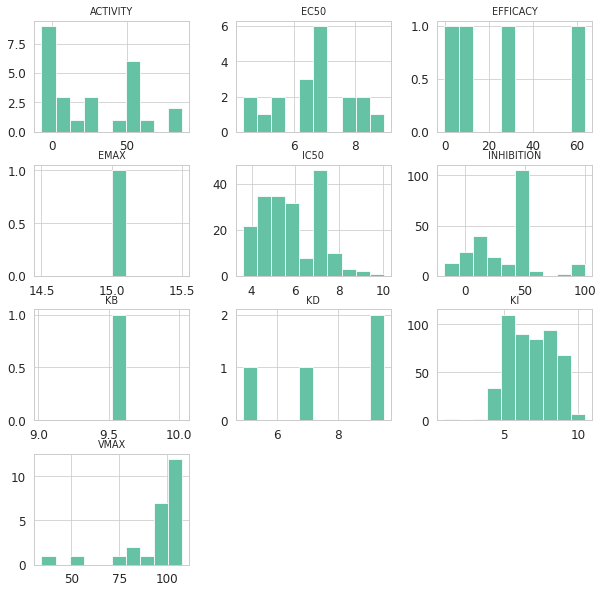

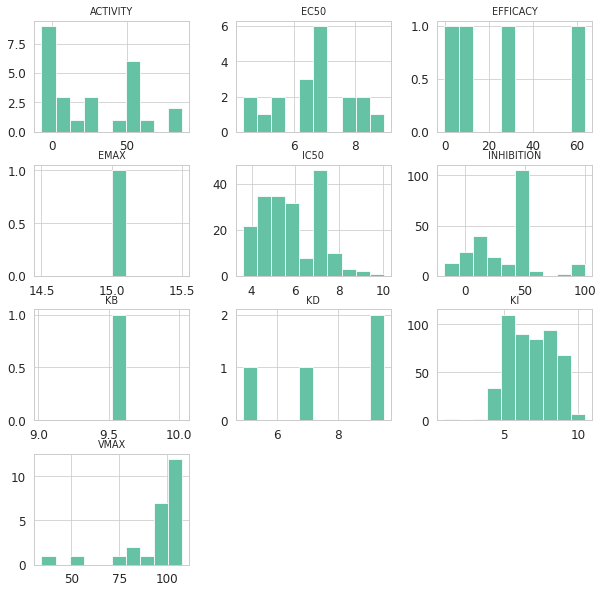

In [42]:
dtc_types=dtc.pivot_table(index = 'Compound_ID', columns = 'End_Point_Standard_Type', values='pDTC_Value', aggfunc='mean')
display(dtc_types.describe())
dtc_types.hist(figsize=(10,10));
dtc_types.hist();

In [43]:
excape=excape.replace('None', np.nan)
excape.head()

,Ambit_InchiKey,Original_Entry_ID,Entrez_ID,Activity_Flag,pXC50,DB,Original_Assay_ID,Tax_ID,Gene_Symbol,Ortholog_Group,SMILES
0,AZGOVLGMSGAOMP-FZYUQVBKNA-N,CHEMBL404232,3359,A,5.52000,chembl20,989092,9606,HTR3A,2102,C=1C=C2C(/C=C/3\C(N(C(N3C)=N)C)=O)=CNC2=CC1
1,BAZZAIKMNMNZJS-PKRZOPRNNA-N,CHEMBL494999,79246,A,7.36000,chembl20,523350,10116,HTR3A,2102,N=1C=2C=CC=C(C)C2N3C(=CC=C3)C1N4CCN(CC4)C(C(=O...
2,ARXTZNGJWWBBMH-LQFNOIFHNA-N,44157937,79246,A,8.52288,pubchem,375321,10116,HTR3A,2102,OC(=NO)CN1CCN(CC1)C2=NC=3C(N4C2=CC=C4)=C(C=CC3)C
3,ASQVLAWCAVGHRV-UHFFFAOYNA-N,CHEMBL576046,79246,A,7.65000,chembl20,592418,10116,HTR3A,2102,N1(C=NC=C1)CCN2CCN(C3=NC4=CC(=CC=C4N5C3=CC=C5)...
4,ATBPRFXCCZLQCU-KHCWMJRFNA-N,CHEMBL40260,3359,A,8.48000,chembl20,3470,9606,HTR3A,2102,C1(C=2N=C(CN=C(N)N)SC2)=CNC=3C1=CC=CC3


,Entrez_ID,pXC50,Original_Assay_ID,Tax_ID,Ortholog_Group
count,649.000000,645.000000,6.490000e+02,649.000000,649.0
mean,16215.274268,6.983770,6.633640e+05,9715.318952,2102.0
std,27698.741204,1.505524,2.569910e+05,207.728422,0.0
min,3359.000000,1.000000,3.123000e+03,9606.000000,2102.0
25%,3359.000000,5.800000,5.369680e+05,9606.000000,2102.0
50%,3359.000000,7.161150,6.525690e+05,9606.000000,2102.0
75%,3359.000000,8.140000,8.059070e+05,9606.000000,2102.0
max,79246.000000,10.500000,1.350972e+06,10116.000000,2102.0


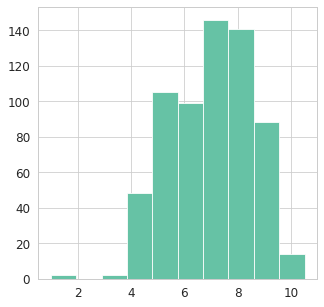

In [44]:
# excape only has one column we care about
display(excape.describe())
excape.pXC50.hist(figsize=(5,5));

# Compare pResponse values across ChEMBL, DTC and Excape-DB
- create a histogram or kde plot with legend showing distributions for all three datasets on the same plot

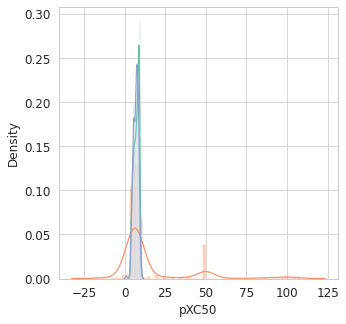

In [45]:
fig, ax = plt.subplots(1,1,figsize = (5,5))
sns.distplot(chembl.pChEMBL_Value, ax=ax)
sns.distplot(dtc.pDTC_Value, ax=ax)
sns.distplot(excape.pXC50, ax=ax);

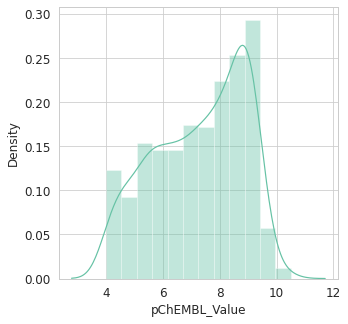

In [46]:
fig, ax = plt.subplots(1,1,figsize = (5,5))
sns.distplot(chembl.pChEMBL_Value, ax=ax)

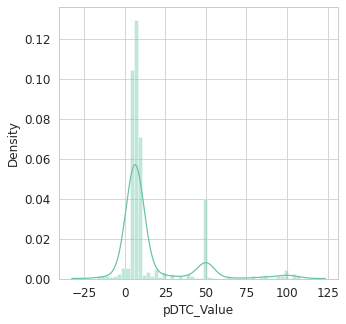

In [47]:
fig, ax = plt.subplots(1,1,figsize = (5,5))
sns.distplot(dtc.pDTC_Value, ax=ax)

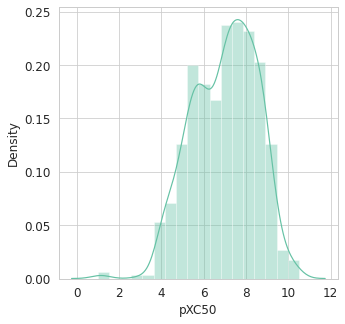

In [48]:
fig, ax = plt.subplots(1,1,figsize = (5,5))
sns.distplot(excape.pXC50, ax=ax);

# Analysis
- what value types you would model and why?
- how would you use this data for a classification model?
- do any of the three datasets include a column you could use for classification?

<p> I would model either pXC50 or pKI values. They are the most abundant in the dataset and commonly used for modeling. pKI is more normally distributed, but pXC50 values allow inclusion of excape data. 

According to some sources, these two datapoints can be combined in various ways, as well, but that's beyond the scope of this class.

I would choose a reasonable IC50 concentration to use as a threshold (perhaps 10uM, or consult with a scientist), and anything with an IC50 above that threshold is inactive (you need more drug to get activity) and IC50s below this threshold is active (you need less drug for activity, meaning the compound is MORE active per unit)

## EDA tips
- Make sure smiles strings exist since that's what AMPL uses
- Compare compounds in each dataset
- Featurize with ECFP fingerprints
- Examine diversity of compound set

# **Final Curation**

Get SMILES for DTC data from chemical identifiers
Since AMPL and other modeling pipelines use SMILES strings, we will use these as our primary data curation tool.
1. open DTC file in google sheets/excel or from the LHS folder menu, right-click on the "HTR3A_DTC.csv" file to download it to your computer and open the file with Excel. 
2. copy/paste the compound ID (ChEMBLXXXXXXX) column into pubchem ID exchange service: https://pubchem.ncbi.nlm.nih.gov/idexchange/idexchange.cgi  (use highlight and click on "Follow-link" option to open the link in your browser)
  - did you get the whole column??
  - Be sure to select the correct registry ID for the input id list
  - Select "Same CID" and SMILES as output

6. upload resulting text files into **AMPL_EDA_07** folder

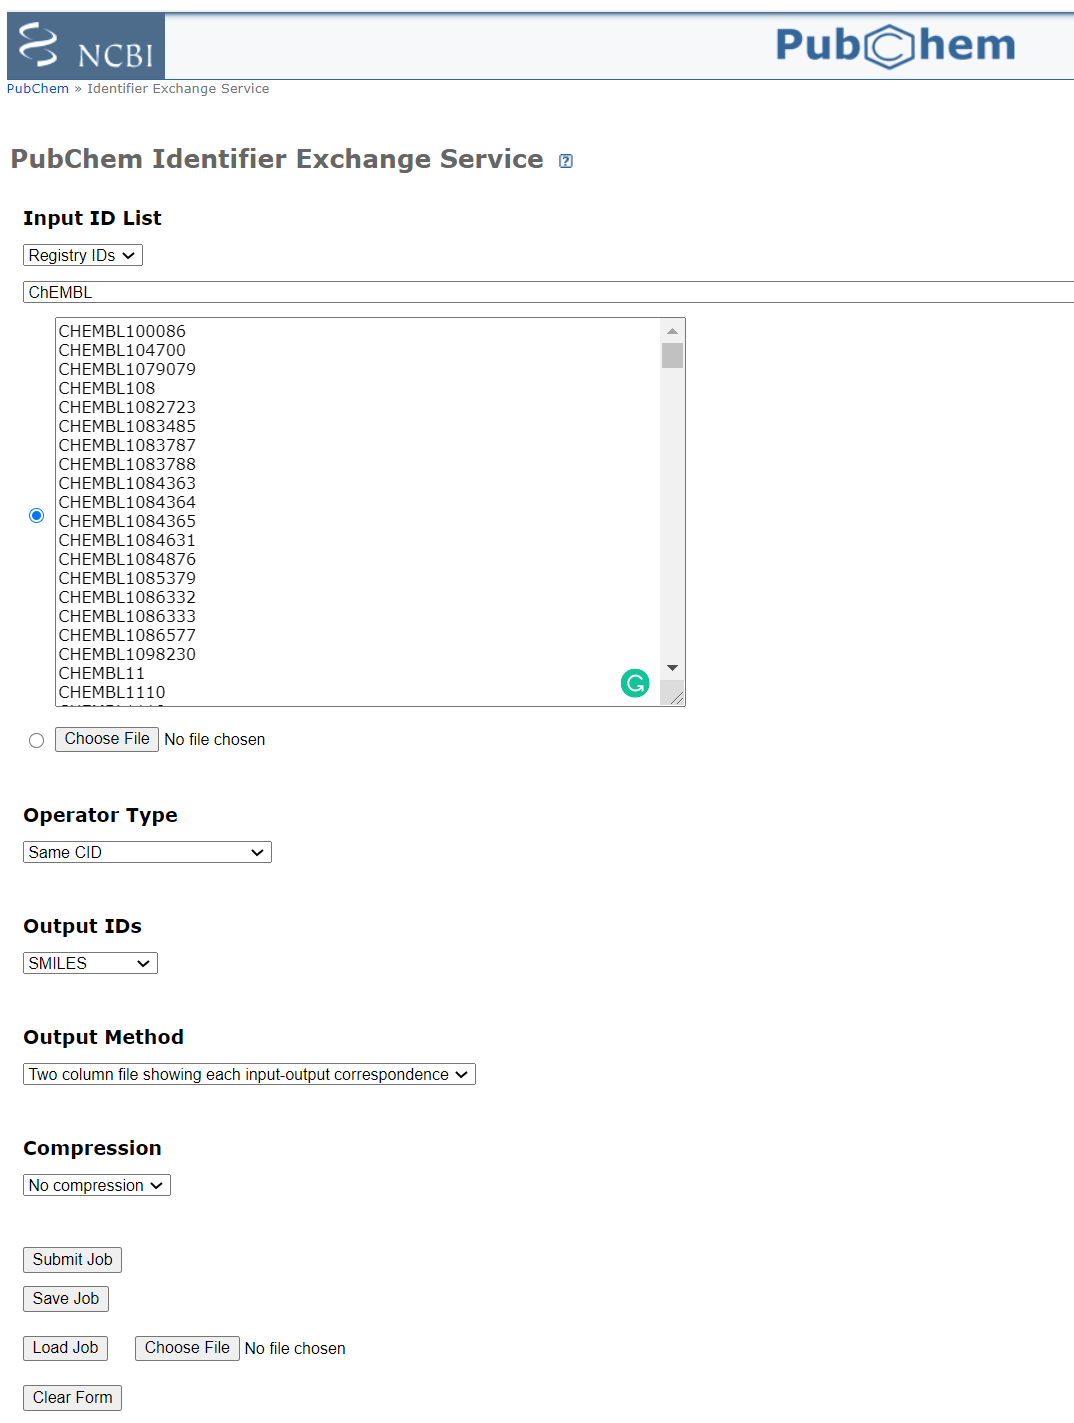

In [49]:
from IPython.display import Image
Image("https://raw.githubusercontent.com/ATOMScience-org/AMPL/master/atomsci/ddm/examples/tutorials/Img/PubChemCIDExchange.png", 
      width = 900, height = 900)

Note, the output from PubChem Identifier Exchange Service can be uploaded into the left hand window of COLAB by dragging and dropping the file. In my case the output file is, `3983437898785642818.txt`

In my case, I have saved the file in GitHub and I am loading it in the following code chunk 

In [ ]:
# the file is also available from my Github link
! wget https://raw.githubusercontent.com/ATOMScience-org/AMPL/master/atomsci/ddm/examples/tutorials/datasets/3983437898785642818.txt
!wget https://raw.githubusercontent.com/ATOMScience-org/AMPL/master/atomsci/ddm/examples/tutorials/datasets/12345.txt

In [51]:
# uncomment if you want to acess the files 
dtc_smiles = pd.read_csv("3983437898785642818.txt", sep='\t', header=None)
dtc_smiles.head(3)

,0,1
0,CHEMBL100086,COC1=CC=CC(=C1)CN2CCN(CC2)C3CCC(CC3)(C4=CC5=C(...
1,CHEMBL104700,C1CC2CCC1N2CC3=CN=CC=C3
2,CHEMBL1079079,COC1=CC=C(C=C1)C2=C(C(=NN2C3=CC=CC=C3[125I])C(...


In [52]:
dtc_smiles=dtc_smiles.rename(columns = {0:'ChEMBL_ID',1:'SMILES'})
dtc_smiles.head()

,ChEMBL_ID,SMILES
0,CHEMBL100086,COC1=CC=CC(=C1)CN2CCN(CC2)C3CCC(CC3)(C4=CC5=C(...
1,CHEMBL104700,C1CC2CCC1N2CC3=CN=CC=C3
2,CHEMBL1079079,COC1=CC=C(C=C1)C2=C(C(=NN2C3=CC=CC=C3[125I])C(...
3,CHEMBL108,C1=CC=C2C(=C1)C=CC3=CC=CC=C3N2C(=O)N
4,CHEMBL1082723,C[C@H]1CC2=C([C@]3(N1)C4=C(C=CC(=C4)Cl)NC3=O)N...


In [53]:
dtc[['Compound_ID']].head(3)

,Compound_ID
0,CHEMBL100086
1,CHEMBL104700
2,CHEMBL1079079


#### Let us explore the `map(dict(zip()))` construct

In [54]:
# map chembl id to smiles using a dict
dtc['SMILES'] = dtc['Compound_ID'].map(dict(zip(dtc_smiles.ChEMBL_ID, dtc_smiles.SMILES)))

In [55]:
# what's missing?
print("No ChemblID in DTC:", len(dtc[dtc['Compound_ID'].isna()]))
print("No SMILES from ChemblID in DTC:", len(dtc[dtc.SMILES.isna()]))

No ChemblID in DTC: 29
No SMILES from ChemblID in DTC: 33


No SMILES for 4 compounds that had ChEMBL IDs. They are 

      Compound_ID	 Standard_inchi_key        	               SMILES
767	CHEMBL3085543	 BXTUHNWXQLWICJ-DIXMSKSGSA-L	
768	CHEMBL3085543	 BXTUHNWXQLWICJ-DIXMSKSGSA-L	
769	CHEMBL3085543	 BXTUHNWXQLWICJ-DIXMSKSGSA-L	
770	CHEMBL3085543	 BXTUHNWXQLWICJ-DIXMSKSGSA-L


Another 29 of them had no ChEMBL IDs 

         Compound_ID	Standard_inchi_key        	SMILES
1281		              ABZSPJVXTTUFAA-UHFFFAOYSA-N	
1282		              ABZSPJVXTTUFAA-UHFFFAOYSA-N	
1283		              ABZSPJVXTTUFAA-UHFFFAOYSA-N	
1284		VBOQYPQEPHKASR-GSVOUGTGSA-N	
1285		PDNJLMZEGXHSCU-GSVOUGTGSA-N	
1286		KIWQWJKWBHZMDT-GSVOUGTGSA-N	
1287		VBOQYPQEPHKASR-UHFFFAOYSA-N	
1288		DYIRSNMPIZZNBK-UHFFFAOYSA-N	
1289		HXTGXYRHXAGCFP-UHFFFAOYSA-N	
1290		WPEBMRNXFWCMHU-UHFFFAOYSA-N	
1291		ZITSATWAZDKOBF-UHFFFAOYSA-N	
1292		KRBFLOBPUMORJO-UHFFFAOYSA-N	
1293		IDRHDKGNUNKODU-UHFFFAOYSA-N	
1294		IVHTZIIPDCREHO-UHFFFAOYSA-N	
1295		WPPPKVSENOHDIG-UHFFFAOYSA-N	
1296		BWGIECJEQVGDRP-UHFFFAOYSA-N	
1297		PKNNCDGLZOSLJS-UHFFFAOYSA-N	
1298		SUGVYNSRNKFXQM-ACSDJOOWSA-N	
1299		QLOOWOVVZLBYHU-UHFFFAOYSA-N	
1300		YPAKIZUIDJVWEU-UHFFFAOYSA-N	
1301		IULBXDZWXBXGNP-UHFFFAOYSA-N	
1302		JBGBKQZMARTYMJ-UHFFFAOYSA-N	
1303		OIOMPFBFUIBOFU-UHFFFAOYSA-N	
1304		YQZJKNSLWYSIQK-UHFFFAOYSA-N	
1305		GKQNHLVTVYRVPU-UHFFFAOYSA-N	
1306		FHGYGOURWHLFKB-UHFFFAOYSA-N	
1307		BYOFGWKOPRCCDL-UHFFFAOYSA-N	
1308		BKOSOHWFMPLYRS-UHFFFAOYSA-N	
1309		HOASDGCNODVMOU-UHFFFAOYSA-N	

In [56]:
# if you want to explore the data outside of COLAB
#  dtc.to_csv("test.csv")

#### For the missing Compound IDs, let us try to recover the SMILES from InChi Keys

In [57]:
dtc[dtc.SMILES.isna()]['Standard_inchi_key'].unique().tolist()

['BXTUHNWXQLWICJ-DIXMSKSGSA-L',
 'ABZSPJVXTTUFAA-UHFFFAOYSA-N',
 'VBOQYPQEPHKASR-GSVOUGTGSA-N',
 'PDNJLMZEGXHSCU-GSVOUGTGSA-N',
 'KIWQWJKWBHZMDT-GSVOUGTGSA-N',
 'VBOQYPQEPHKASR-UHFFFAOYSA-N',
 'DYIRSNMPIZZNBK-UHFFFAOYSA-N',
 'HXTGXYRHXAGCFP-UHFFFAOYSA-N',
 'WPEBMRNXFWCMHU-UHFFFAOYSA-N',
 'ZITSATWAZDKOBF-UHFFFAOYSA-N',
 'KRBFLOBPUMORJO-UHFFFAOYSA-N',
 'IDRHDKGNUNKODU-UHFFFAOYSA-N',
 'IVHTZIIPDCREHO-UHFFFAOYSA-N',
 'WPPPKVSENOHDIG-UHFFFAOYSA-N',
 'BWGIECJEQVGDRP-UHFFFAOYSA-N',
 'PKNNCDGLZOSLJS-UHFFFAOYSA-N',
 'SUGVYNSRNKFXQM-ACSDJOOWSA-N',
 'QLOOWOVVZLBYHU-UHFFFAOYSA-N',
 'YPAKIZUIDJVWEU-UHFFFAOYSA-N',
 'IULBXDZWXBXGNP-UHFFFAOYSA-N',
 'JBGBKQZMARTYMJ-UHFFFAOYSA-N',
 'OIOMPFBFUIBOFU-UHFFFAOYSA-N',
 'YQZJKNSLWYSIQK-UHFFFAOYSA-N',
 'GKQNHLVTVYRVPU-UHFFFAOYSA-N',
 'FHGYGOURWHLFKB-UHFFFAOYSA-N',
 'BYOFGWKOPRCCDL-UHFFFAOYSA-N',
 'BKOSOHWFMPLYRS-UHFFFAOYSA-N',
 'HOASDGCNODVMOU-UHFFFAOYSA-N']

The file 12345.txt is the output from NCBI ID Exchange using the above 29 InChi keys as input

In [58]:
dtc.head(2)

,Compound_ID,Uniprot_ID,Compound_Name,Standard_inchi_key,Max_Phase,Target_Pref_Name,Gene_Names,Target_Class,Wild_type_or_mutant,Mutation_information,PubMed_ID,End_Point_Standard_Type,End_Point_Standard_Relation,End_Point_Standard_Value,End_Point_Standard_Units,Endpoint_Mode_of_Action,Assay_Format,Assay_Type,Assay_Sub_Type,Inhibitor_Type,Detection_Technology,Compound_concentration_value,Compound_concentration_value_units,Substrate_type,Substrate_Type_Standard_Relation,Substrate_Type_Standard_Value,Substrate_Type_Standard_Units,Assay_cell_line,Assay_Description,Activity_Comments,Title,Journal,Year,Volume,Issue,Authors,Annotation_Comments,Assay_ID,DTC_Tid,DTC_Activity_ID,DTC_Molregno,Record_ID,DTC_Document_ID,pDTC_Value,SMILES
0,CHEMBL100086,P46098,NaN,OSVMSQACZRYAPT-UHFFFAOYSA-N,0,SEROTONIN 3A (5-HT3A) RECEPTOR,HTR3A,Ion channel,NaN,NaN,12482441.0,IC50,>,100000.0,NM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inhibitory concentration required against 5-HT...,NaN,Development of a presynaptic 5-HT1A antagonist.,Bioorg. Med. Chem. Lett.,2003.0,13.0,2.0,"Mattson RJ, Catt JD, Sloan CP, Gao Q, Carter R...",NaN,3062.0,DTCT0023221,1489397,DTCC00263953,917398,5847,4.0,COC1=CC=CC(=C1)CN2CCN(CC2)C3CCC(CC3)(C4=CC5=C(...
1,CHEMBL104700,P46098,NaN,SCDKHPSUXHBJDJ-UHFFFAOYSA-N,0,SEROTONIN 3A (5-HT3A) RECEPTOR,HTR3A,Ion channel,NaN,NaN,22607684.0,KI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inhibition of 5-HT3 receptor,Not Determined,7-Azabicyclo[2.2.1]heptane as a scaffold for t...,Bioorg. Med. Chem. Lett.,2012.0,22.0,12.0,"Banister SD, Rendina LM, Kassiou M",NaN,820298.0,DTCT0023221,10478126,DTCC00272114,931177,48255,NaN,C1CC2CCC1N2CC3=CN=CC=C3


In [59]:
# if you havent completed the conversion, you can access the file from my GitHub link
inchi_smiles = pd.read_csv("12345.txt", sep='\t', header=None)
inchi_smiles.head(3)

,0,1
0,BXTUHNWXQLWICJ-DIXMSKSGSA-L,NaN
1,ABZSPJVXTTUFAA-UHFFFAOYSA-N,CC(=O)NC1=CC=C(C=C1)C(=O)NC2=C(C=CC(=C2)C3=CC=...
2,VBOQYPQEPHKASR-GSVOUGTGSA-N,C(CS(=O)(=O)O)[C@H](C(=O)O)N


In [60]:
inchi_smiles=inchi_smiles.rename(columns = {0:'INCHIKEY',1:'SMILES'})
inchi_smiles

,INCHIKEY,SMILES
0,BXTUHNWXQLWICJ-DIXMSKSGSA-L,NaN
1,ABZSPJVXTTUFAA-UHFFFAOYSA-N,CC(=O)NC1=CC=C(C=C1)C(=O)NC2=C(C=CC(=C2)C3=CC=...
2,VBOQYPQEPHKASR-GSVOUGTGSA-N,C(CS(=O)(=O)O)[C@H](C(=O)O)N
3,PDNJLMZEGXHSCU-GSVOUGTGSA-N,C(CS(=O)O)[C@H](C(=O)O)N
4,KIWQWJKWBHZMDT-GSVOUGTGSA-N,C1CSC(=O)[C@@H]1N
...,...,...
23,GKQNHLVTVYRVPU-UHFFFAOYSA-N,CC1=NC2=C(C=C(S2)C3=CC=CC=C3)C(=N1)SCC4=CC=CC=C4
24,FHGYGOURWHLFKB-UHFFFAOYSA-N,CC(=O)CSC1=NC=NC2=C1C=C(S2)C3=CC=CC=C3
25,BYOFGWKOPRCCDL-UHFFFAOYSA-N,C1=CC=C(C=C1)C2=CC3=C(N=CN=C3S2)OC4=CC=C(C=C4)C=O
26,BKOSOHWFMPLYRS-UHFFFAOYSA-N,CC1=C(SC2=NC=NC(=C12)NC)C


In [61]:
dtc['SMILES'].isna().sum()
dtc['Standard_inchi_key'].isnull().sum()
dtc['SMILES'].isnull().sum()
dtc['SMILES'].head(3)

0    COC1=CC=CC(=C1)CN2CCN(CC2)C3CCC(CC3)(C4=CC5=C(...
1                              C1CC2CCC1N2CC3=CN=CC=C3
2    COC1=CC=C(C=C1)C2=C(C(=NN2C3=CC=CC=C3[125I])C(...
Name: SMILES, dtype: object

In [62]:
my_dict = dict(zip( inchi_smiles.INCHIKEY, inchi_smiles.SMILES))
dtc['SMILES1'] = dtc['Standard_inchi_key'].map(my_dict)

In [63]:
# checking

print(dtc['SMILES'].isna().sum())
print(chembl['Smiles'].isna().sum())
print(excape['SMILES'].isna().sum())


33
1
0


In [64]:
dtc['SMILES']= np.where(dtc['SMILES'].isnull(), dtc['SMILES1'], dtc['SMILES'])

In [65]:
dtc = dtc.drop(['SMILES1'], axis=1)

In [66]:
dtc=dtc.replace('None', np.nan)

# EDA: Examine compound overlaps
Start with questions you have about the compounds at this point in time, such as:
- what compounds are in each set? do they overlap?
- are the compounds diverse or all very similar to each other?

In [67]:
from matplotlib_venn import venn3
from matplotlib_venn import venn2

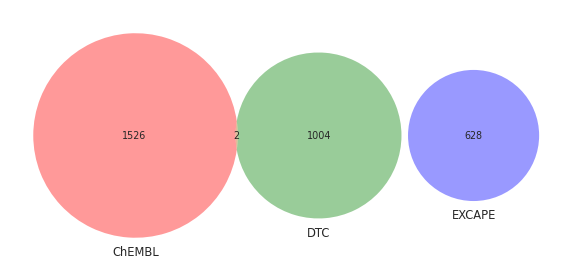

In [68]:
# overlaps from SMILES strings
venn3([set(chembl.Smiles),
           set(dtc.SMILES),
           set(excape.SMILES)],
          set_labels = ['ChEMBL', 'DTC','EXCAPE']);

### venn diagram 

For overlapping ChEMBL IDs - mpv requires sets not lists

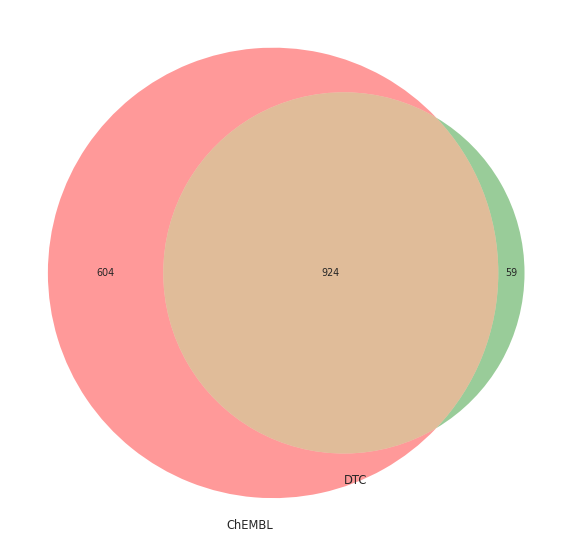

In [69]:
venn2([set(chembl.Molecule_ChEMBL_ID), set(dtc.Compound_ID)], set_labels=['ChEMBL','DTC']);

The chembl IDs overlap, why not the smiles strings? One explanation is that each database's SMILES string representations are slightly different. Answer? **STANDARDIZE the smiles strings.**

# **Curation step:** Standardize smiles strings, drop rows without base smiles

In [70]:
chembl['base_rdkit_smiles'] = chembl.Smiles.apply(curate_data.base_smiles_from_smiles)
print(len(chembl.Smiles))
print(len(chembl.Smiles.unique()))
print(len(chembl.base_rdkit_smiles.unique()))

1950
1528
1528


In [71]:
chembl[chembl.base_rdkit_smiles=='']

,Molecule_ChEMBL_ID,Molecule_Name,Molecule_Max_Phase,Molecular_Weight,#RO5_Violations,AlogP,Compound_Key,Smiles,Standard_Type,Standard_Relation,Standard_Value,Standard_Units,pChEMBL_Value,Data_Validity_Comment,Comment,Uo_Units,Ligand_Efficiency_BEI,Ligand_Efficiency_LE,Ligand_Efficiency_LLE,Ligand_Efficiency_SEI,Potential_Duplicate,Assay_ChEMBL_ID,Assay_Description,Assay_Type,BAO_Format_ID,BAO_Label,Assay_Organism,Assay_Tissue_ChEMBL_ID,Assay_Tissue_Name,Assay_Cell_Type,Assay_Subcellular_Fraction,Assay_Parameters,Assay_Variant_Accession,Assay_Variant_Mutation,Target_ChEMBL_ID,Target_Name,Target_Organism,Target_Type,Document_ChEMBL_ID,Source_ID,Source_Description,Document_Journal,Document_Year,Cell_ChEMBL_ID,Properties,Standard_Value_nM,base_rdkit_smiles
1638,CHEMBL4532510,NaN,0.0,NaN,NaN,NaN,NaN,NaN,Inhibition,'=',4.05,%,NaN,NaN,Not Active,UO_0000187,NaN,NaN,NaN,NaN,False,CHEMBL4507808,GPCRScan assay: inhibition of 5-HT3,B,BAO_0000357,single protein format,Homo sapiens,NaN,NaN,NaN,NaN,Parental cells: HEKT | PMID: 2164935/8436978 |...,NaN,NaN,CHEMBL1899,Serotonin 3a (5-HT3a) receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL4507304,54,Donated Chemical Probes - SGC Frankfurt,NaN,NaN,NaN,Compound concentration None 10.0 uM,4.05,


In [72]:
chembl=chembl.replace('',np.nan)
chembl[chembl.base_rdkit_smiles.isna()]

,Molecule_ChEMBL_ID,Molecule_Name,Molecule_Max_Phase,Molecular_Weight,#RO5_Violations,AlogP,Compound_Key,Smiles,Standard_Type,Standard_Relation,Standard_Value,Standard_Units,pChEMBL_Value,Data_Validity_Comment,Comment,Uo_Units,Ligand_Efficiency_BEI,Ligand_Efficiency_LE,Ligand_Efficiency_LLE,Ligand_Efficiency_SEI,Potential_Duplicate,Assay_ChEMBL_ID,Assay_Description,Assay_Type,BAO_Format_ID,BAO_Label,Assay_Organism,Assay_Tissue_ChEMBL_ID,Assay_Tissue_Name,Assay_Cell_Type,Assay_Subcellular_Fraction,Assay_Parameters,Assay_Variant_Accession,Assay_Variant_Mutation,Target_ChEMBL_ID,Target_Name,Target_Organism,Target_Type,Document_ChEMBL_ID,Source_ID,Source_Description,Document_Journal,Document_Year,Cell_ChEMBL_ID,Properties,Standard_Value_nM,base_rdkit_smiles
1638,CHEMBL4532510,NaN,0.0,NaN,NaN,NaN,NaN,NaN,Inhibition,'=',4.05,%,NaN,NaN,Not Active,UO_0000187,NaN,NaN,NaN,NaN,False,CHEMBL4507808,GPCRScan assay: inhibition of 5-HT3,B,BAO_0000357,single protein format,Homo sapiens,NaN,NaN,NaN,NaN,Parental cells: HEKT | PMID: 2164935/8436978 |...,NaN,NaN,CHEMBL1899,Serotonin 3a (5-HT3a) receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL4507304,54,Donated Chemical Probes - SGC Frankfurt,NaN,NaN,NaN,Compound concentration None 10.0 uM,4.05,NaN


In [73]:
chembl=chembl[~chembl.base_rdkit_smiles.isna()]

In [74]:
chembl[chembl.base_rdkit_smiles=='']

,Molecule_ChEMBL_ID,Molecule_Name,Molecule_Max_Phase,Molecular_Weight,#RO5_Violations,AlogP,Compound_Key,Smiles,Standard_Type,Standard_Relation,Standard_Value,Standard_Units,pChEMBL_Value,Data_Validity_Comment,Comment,Uo_Units,Ligand_Efficiency_BEI,Ligand_Efficiency_LE,Ligand_Efficiency_LLE,Ligand_Efficiency_SEI,Potential_Duplicate,Assay_ChEMBL_ID,Assay_Description,Assay_Type,BAO_Format_ID,BAO_Label,Assay_Organism,Assay_Tissue_ChEMBL_ID,Assay_Tissue_Name,Assay_Cell_Type,Assay_Subcellular_Fraction,Assay_Parameters,Assay_Variant_Accession,Assay_Variant_Mutation,Target_ChEMBL_ID,Target_Name,Target_Organism,Target_Type,Document_ChEMBL_ID,Source_ID,Source_Description,Document_Journal,Document_Year,Cell_ChEMBL_ID,Properties,Standard_Value_nM,base_rdkit_smiles


## Standardize other datasets
- what do you notice about the number of unique smiles strings before and after standardization?
- what does this mean for the nature of the compounds in a given dataset?
- hint: look at chemical identifiers that have the same base_rdkit_smiles, and the 'DB' column in excape

In [75]:
dtc['base_rdkit_smiles'] = dtc.SMILES.apply(curate_data.base_smiles_from_smiles)
dtc=dtc.replace('',np.nan)
dtc[dtc.base_rdkit_smiles.isna()]

,Compound_ID,Uniprot_ID,Compound_Name,Standard_inchi_key,Max_Phase,Target_Pref_Name,Gene_Names,Target_Class,Wild_type_or_mutant,Mutation_information,PubMed_ID,End_Point_Standard_Type,End_Point_Standard_Relation,End_Point_Standard_Value,End_Point_Standard_Units,Endpoint_Mode_of_Action,Assay_Format,Assay_Type,Assay_Sub_Type,Inhibitor_Type,Detection_Technology,Compound_concentration_value,Compound_concentration_value_units,Substrate_type,Substrate_Type_Standard_Relation,Substrate_Type_Standard_Value,Substrate_Type_Standard_Units,Assay_cell_line,Assay_Description,Activity_Comments,Title,Journal,Year,Volume,Issue,Authors,Annotation_Comments,Assay_ID,DTC_Tid,DTC_Activity_ID,DTC_Molregno,Record_ID,DTC_Document_ID,pDTC_Value,SMILES,base_rdkit_smiles
767,CHEMBL3085543,P46098,NaN,BXTUHNWXQLWICJ-DIXMSKSGSA-L,0,SEROTONIN 3A (5-HT3A) RECEPTOR,HTR3A,Ion channel,NaN,NaN,17722904.0,IC50,>,100000.0,NM,NaN,cell_based,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HEK293,Antagonist activity at human 5HT3A receptor ex...,NaN,Pharmacological characteristics and binding mo...,J. Med. Chem.,2007.0,50.0,19.0,"Jensen AA, Zlotos DP, Liljefors T",NaN,445995.0,DTCT0023221,2125488,DTCC01408495,1987064,23555,4.0,NaN,NaN
768,CHEMBL3085543,P46098,NaN,BXTUHNWXQLWICJ-DIXMSKSGSA-L,0,SEROTONIN 3A (5-HT3A) RECEPTOR,HTR3A,Ion channel,NaN,NaN,17722904.0,IC50,>,100000.0,NM,NaN,cell_based,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HEK293,Antagonist activity at human 5HT3A receptor ex...,NaN,Pharmacological characteristics and binding mo...,J. Med. Chem.,2007.0,50.0,19.0,"Jensen AA, Zlotos DP, Liljefors T",NaN,445995.0,DTCT0023221,2125489,DTCC01408495,1987064,23555,4.0,NaN,NaN
769,CHEMBL3085543,P46098,NaN,BXTUHNWXQLWICJ-DIXMSKSGSA-L,0,SEROTONIN 3A (5-HT3A) RECEPTOR,HTR3A,Ion channel,NaN,NaN,17722904.0,KI,>,100000.0,NM,NaN,cell_based,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HEK293,Displacement of [3H]GR65630 from human 5HT3A r...,NaN,Pharmacological characteristics and binding mo...,J. Med. Chem.,2007.0,50.0,19.0,"Jensen AA, Zlotos DP, Liljefors T",NaN,445992.0,DTCT0023221,2125166,DTCC01408495,1987064,23555,4.0,NaN,NaN
770,CHEMBL3085543,P46098,NaN,BXTUHNWXQLWICJ-DIXMSKSGSA-L,0,SEROTONIN 3A (5-HT3A) RECEPTOR,HTR3A,Ion channel,NaN,NaN,17722904.0,KI,>,100000.0,NM,NaN,cell_based,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HEK293,Displacement of [3H]GR65630 from human 5HT3A r...,NaN,Pharmacological characteristics and binding mo...,J. Med. Chem.,2007.0,50.0,19.0,"Jensen AA, Zlotos DP, Liljefors T",NaN,445992.0,DTCT0023221,2125167,DTCC01408495,1987064,23555,4.0,NaN,NaN
1294,NaN,P46098,PU07,IVHTZIIPDCREHO-UHFFFAOYSA-N,0,SEROTONIN 3A (5-HT3A) RECEPTOR,HTR3A,Ion channel,NaN,NaN,22589534.0,IC50,=,100000.0,NM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DTCT0023221,14724072,DTCC01745334,2102800,68163,4.0,NaN,NaN


In [76]:
dtc = dtc[~dtc.base_rdkit_smiles.isna()]

In [77]:
dtc[dtc.base_rdkit_smiles=='']

,Compound_ID,Uniprot_ID,Compound_Name,Standard_inchi_key,Max_Phase,Target_Pref_Name,Gene_Names,Target_Class,Wild_type_or_mutant,Mutation_information,PubMed_ID,End_Point_Standard_Type,End_Point_Standard_Relation,End_Point_Standard_Value,End_Point_Standard_Units,Endpoint_Mode_of_Action,Assay_Format,Assay_Type,Assay_Sub_Type,Inhibitor_Type,Detection_Technology,Compound_concentration_value,Compound_concentration_value_units,Substrate_type,Substrate_Type_Standard_Relation,Substrate_Type_Standard_Value,Substrate_Type_Standard_Units,Assay_cell_line,Assay_Description,Activity_Comments,Title,Journal,Year,Volume,Issue,Authors,Annotation_Comments,Assay_ID,DTC_Tid,DTC_Activity_ID,DTC_Molregno,Record_ID,DTC_Document_ID,pDTC_Value,SMILES,base_rdkit_smiles


In [78]:
excape['base_rdkit_smiles'] = excape.SMILES.apply(curate_data.base_smiles_from_smiles)

In [79]:
excape = excape.replace('',np.nan)
excape[excape.base_rdkit_smiles.isna()]

,Ambit_InchiKey,Original_Entry_ID,Entrez_ID,Activity_Flag,pXC50,DB,Original_Assay_ID,Tax_ID,Gene_Symbol,Ortholog_Group,SMILES,base_rdkit_smiles


In [80]:
dtc.iloc[:, [-1, -2]].head(3)

,base_rdkit_smiles,SMILES
0,COc1cccc(CN2CCN(C3CCC(O)(c4ccc5c(c4)OCO5)CC3)C...,COC1=CC=CC(=C1)CN2CCN(CC2)C3CCC(CC3)(C4=CC5=C(...
1,c1cncc(CN2C3CCC2CC3)c1,C1CC2CCC1N2CC3=CN=CC=C3
2,COc1ccc(-c2c(C#N)c(C(=O)NN3CCCCC3)nn2-c2ccccc2...,COC1=CC=C(C=C1)C2=C(C(=NN2C3=CC=CC=C3[125I])C(...


In [81]:
excape.iloc[:, [-1, -2]].head(3)

,base_rdkit_smiles,SMILES
0,CN1C(=N)N(C)/C(=C/c2c[nH]c3ccccc23)C1=O,C=1C=C2C(/C=C/3\C(N(C(N3C)=N)C)=O)=CNC2=CC1
1,Cc1cccc2nc(N3CCN(C(C(=O)O)c4ccccc4)CC3)c3cccn3c12,N=1C=2C=CC=C(C)C2N3C(=CC=C3)C1N4CCN(CC4)C(C(=O...
2,Cc1cccc2nc(N3CCN(CC(O)=NO)CC3)c3cccn3c12,OC(=NO)CN1CCN(CC1)C2=NC=3C(N4C2=CC=C4)=C(C=CC3)C


**Note the name `Smiles` compared to dtc and excape**

In [82]:
chembl[['base_rdkit_smiles','Smiles']].head(3)

,base_rdkit_smiles,Smiles
0,CC1(C)C(=O)N(Cc2ccc(Cl)cc2Cl)C(=O)N1CCCCCN1CCN...,CC1(C)C(=O)N(Cc2ccc(Cl)cc2Cl)C(=O)N1CCCCCN1CCN...
1,NCC(=O)O,NCC(=O)O
2,O=C1c2cccc3[nH]c(=O)n(c23)CCN1[C@@H]1CN2CCC1CC2,O=C1c2cccc3[nH]c(=O)n(c23)CCN1[C@@H]1CN2CCC1CC2


# **Curation step:** Save standardized datasets

**If want to save the files for later use, mount your google drive and create a folder and save it there. Please note that in this step, you are about to create a folder called `AMPL_EDA_07` in Google Drive.**

In [83]:
%%bash 
mkdir -p /content/drive/MyDrive/AMPL_EDA_07

In [84]:
chembl.to_csv("/content/drive/MyDrive/AMPL_EDA_07/HTR3A_ChEMBL_SMILES_std.csv")
dtc.to_csv("/content/drive/MyDrive/AMPL_EDA_07/HTR3A_DTC_SMILES_std.csv")
excape.to_csv("/content/drive/MyDrive/AMPL_EDA_07/HTR3A_Excape_SMILES_std.csv")

## Examine compound overlaps from standardized smiles strings
- create venn diagram with 3 circles for all 3 datasets

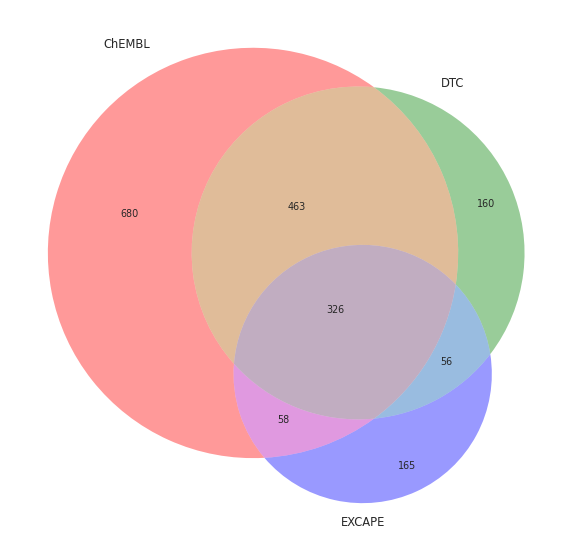

In [85]:
mpv.venn3([set(chembl.base_rdkit_smiles),
           set(dtc.base_rdkit_smiles),
           set(excape.base_rdkit_smiles)],
          set_labels = ['ChEMBL', 'DTC','EXCAPE']);

That's more like it. For even further overlaps, it's possible to pass all of them through the pubchem ID exchange: use input as smiles and output as smiles, then create base_rdkit_smiles again. You should see some increase in overlap with this pre-processing step.

# EDA: Examine compound diversity

 If you want to restart, you can start from here. Please uncomment the following code chunk 

In [86]:
# chembl=pd.read_csv("/content/drive/MyDrive/CE4511/HTR3A_ChEMBL_SMILES_std.csv", index_col=0)
# dtc=pd.read_csv("/content/drive/MyDrive/CE4511/HTR3A_DTC_SMILES_std.csv", index_col=0)
# excape=pd.read_csv("/content/drive/MyDrive/CE4511/HTR3A_Excape_SMILES_std.csv", index_col=0)

In [87]:
sns.set_context('poster')

array([0.93548387, 0.86206897, 0.98076923, ..., 0.88235294, 0.84810127,
       0.9047619 ])

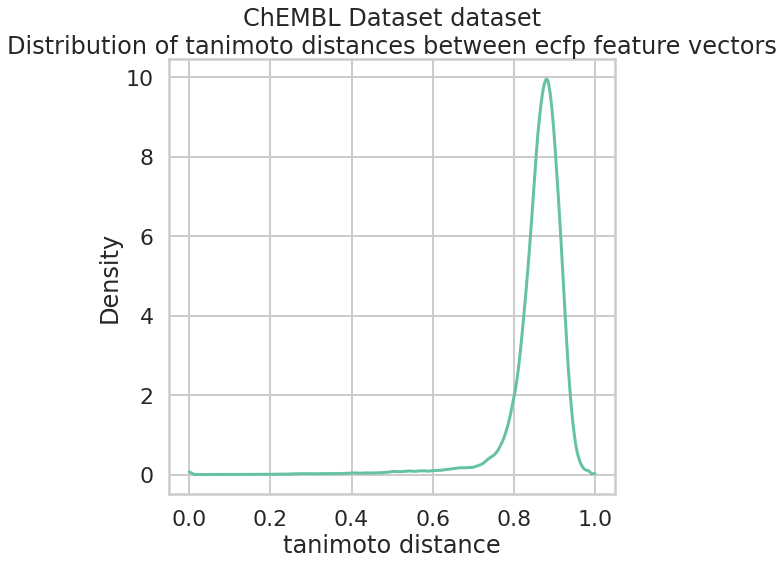

In [88]:
dp.plot_tani_dist_distr(chembl, 'base_rdkit_smiles', 'ChEMBL Dataset')

In [89]:
chembl[['Molecule_ChEMBL_ID','base_rdkit_smiles','pChEMBL_Value']].head(3)

,Molecule_ChEMBL_ID,base_rdkit_smiles,pChEMBL_Value
0,CHEMBL3233676,CC1(C)C(=O)N(Cc2ccc(Cl)cc2Cl)C(=O)N1CCCCCN1CCN...,NaN
1,CHEMBL773,NCC(=O)O,NaN
2,CHEMBL3261486,O=C1c2cccc3[nH]c(=O)n(c23)CCN1[C@@H]1CN2CCC1CC2,NaN


Computing fingerprints...
Done
Computing Tanimoto distance matrix...
Done


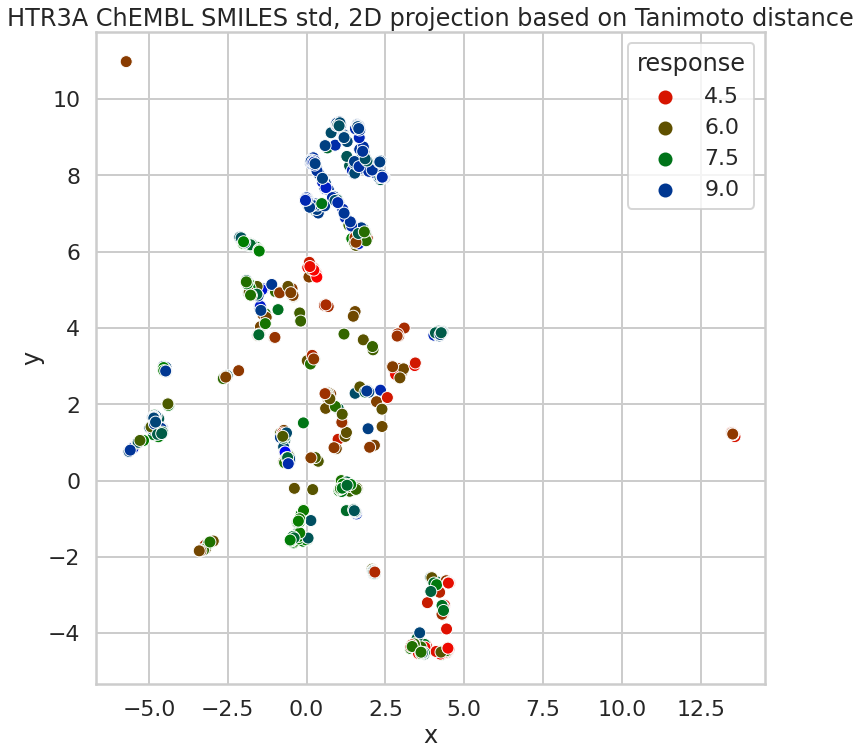

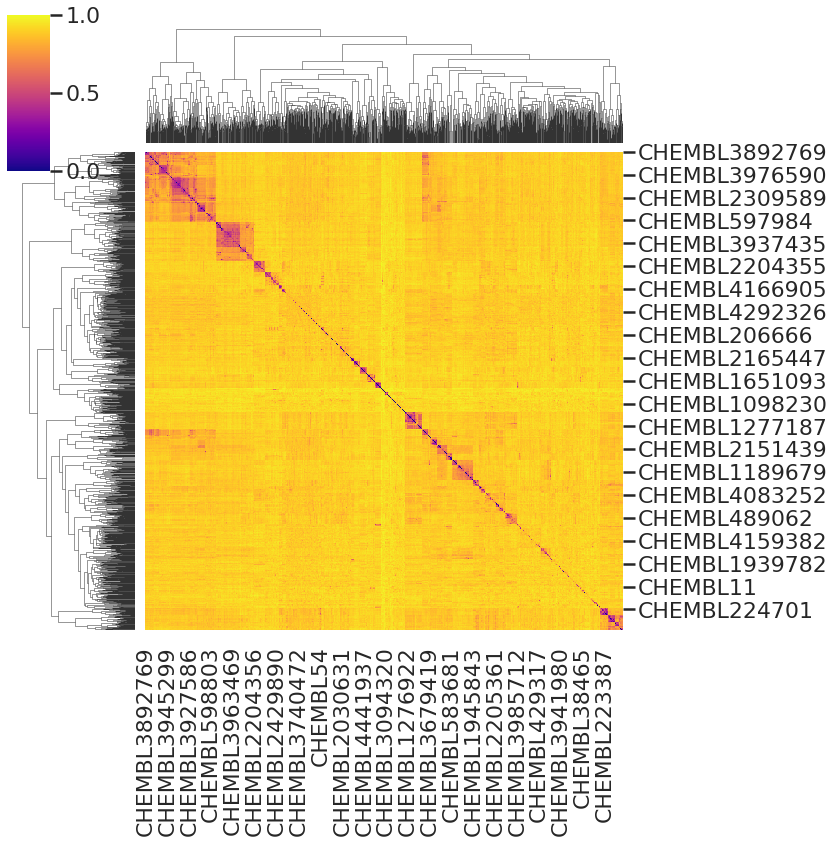

In [90]:
dp.diversity_plots(dset_key='/content/drive/MyDrive/AMPL_EDA_07/HTR3A_ChEMBL_SMILES_std.csv',
                   datastore=False, 
                   id_col ='Molecule_ChEMBL_ID', 
                   smiles_col = 'base_rdkit_smiles', 
                   is_base_smiles=True, 
                   response_col = 'pChEMBL_Value')

## Create plots for DTC, Excape
- What happens when you change the ecfp radius?
- bonus: try creating MCS plots by looking at the documentation of the diversity_plots function
- warning: it is very slow for >1000 ish compounds. 
- extra bonus: select a random subset of 1000 compounds and create the MCS plots.

In [91]:
dtc['base_rdkit_smiles']

0       COc1cccc(CN2CCN(C3CCC(O)(c4ccc5c(c4)OCO5)CC3)C...
1                                  c1cncc(CN2C3CCC2CC3)c1
2       COc1ccc(-c2c(C#N)c(C(=O)NN3CCCCC3)nn2-c2ccccc2...
3                            NC(=O)N1c2ccccc2C=Cc2ccccc21
4       C[C@H]1Cc2c([nH]c3cc(Cl)c(F)cc23)[C@@]2(N1)C(=...
                              ...                        
1305                Cc1nc(SCc2ccccc2)c2cc(-c3ccccc3)sc2n1
1306                     CC(=O)CSc1ncnc2sc(-c3ccccc3)cc12
1307               O=Cc1ccc(Oc2ncnc3sc(-c4ccccc4)cc23)cc1
1308                                CNc1ncnc2sc(C)c(C)c12
1309                                   CSc1ncnc2sc(C)cc12
Name: base_rdkit_smiles, Length: 1305, dtype: object

In [92]:
# Because we made some changes to DTC. We need to get the std SMILES again

In [93]:
# dtc['base_rdkit_smiles'] = dtc.SMILES.apply(curate_data.base_smiles_from_smiles)
# dtc.to_csv("/content/drive/MyDrive/AMPL_EDA_07/HTR3A_DTC_SMILES_std.csv")

In [94]:
# dtc=pd.read_csv("/content/drive/MyDrive/AMPL_EDA_07/HTR3A_DTC_SMILES_std.csv", index_col=0)

In [95]:
# dtc.head()

array([0.7761194 , 0.84536082, 0.89473684, ..., 0.63265306, 0.76785714,
       0.71428571])

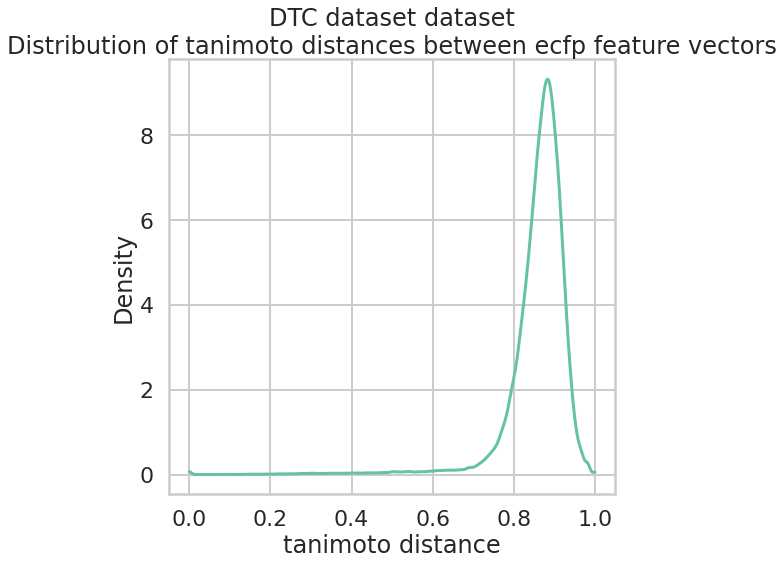

In [96]:
dp.plot_tani_dist_distr(dtc, 'base_rdkit_smiles', 'DTC dataset') # check for NA or other types

In [97]:
dtc[['Compound_ID','base_rdkit_smiles','pDTC_Value']]

,Compound_ID,base_rdkit_smiles,pDTC_Value
0,CHEMBL100086,COc1cccc(CN2CCN(C3CCC(O)(c4ccc5c(c4)OCO5)CC3)C...,4.0
1,CHEMBL104700,c1cncc(CN2C3CCC2CC3)c1,NaN
2,CHEMBL1079079,COc1ccc(-c2c(C#N)c(C(=O)NN3CCCCC3)nn2-c2ccccc2...,50.0
3,CHEMBL108,NC(=O)N1c2ccccc2C=Cc2ccccc21,50.0
4,CHEMBL1082723,C[C@H]1Cc2c([nH]c3cc(Cl)c(F)cc23)[C@@]2(N1)C(=...,5.0
...,...,...,...
1305,NaN,Cc1nc(SCc2ccccc2)c2cc(-c3ccccc3)sc2n1,4.0
1306,NaN,CC(=O)CSc1ncnc2sc(-c3ccccc3)cc12,4.0
1307,NaN,O=Cc1ccc(Oc2ncnc3sc(-c4ccccc4)cc23)cc1,4.0
1308,NaN,CNc1ncnc2sc(C)c(C)c12,4.0


Computing fingerprints...
Done
Computing Tanimoto distance matrix...
Done


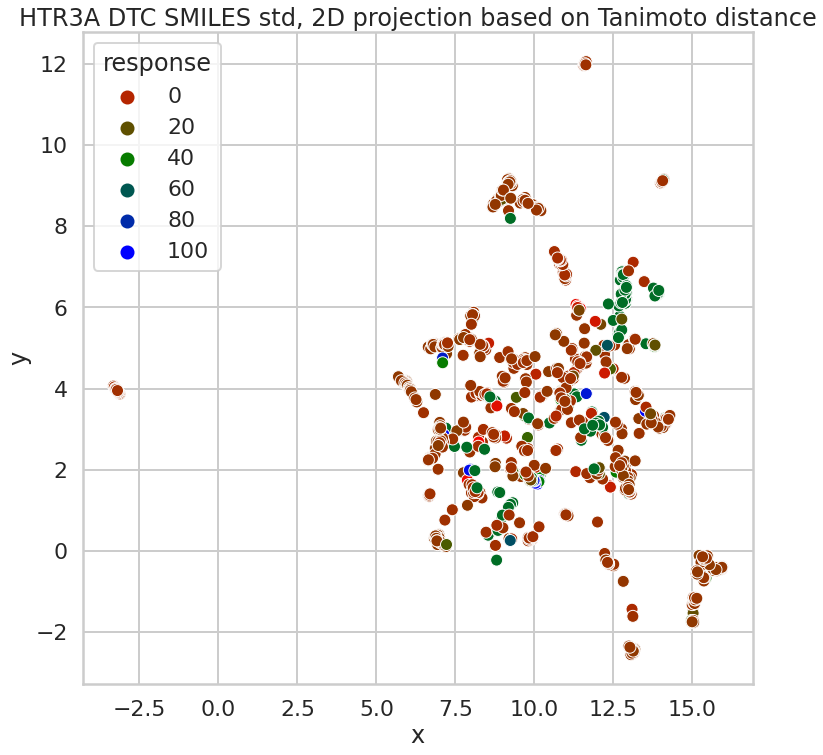

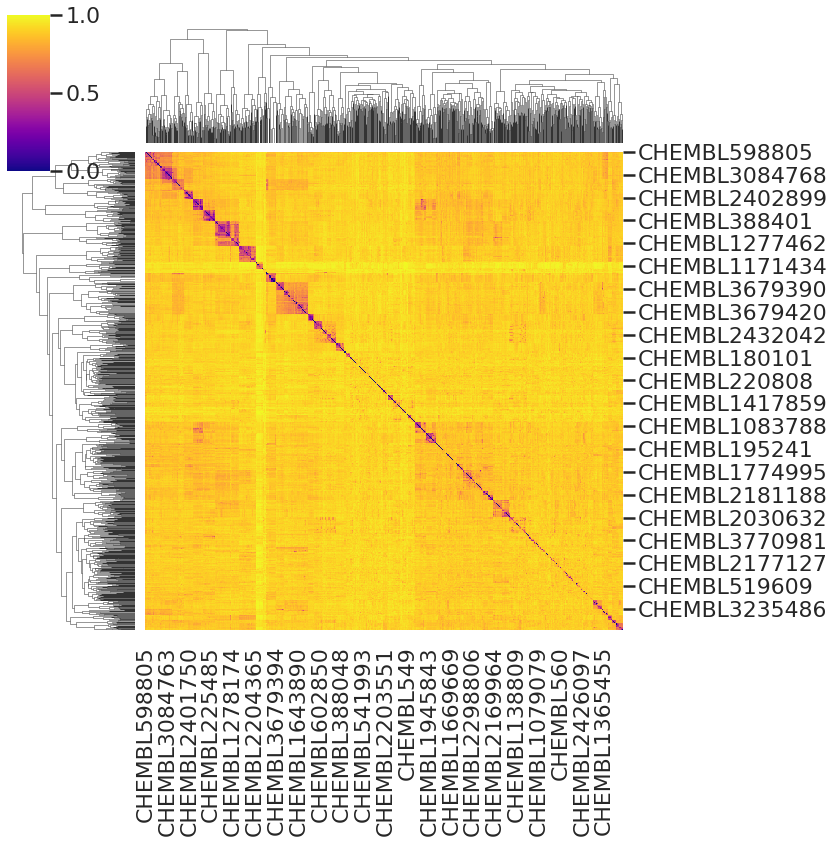

In [98]:
dp.diversity_plots('/content/drive/MyDrive/AMPL_EDA_07/HTR3A_DTC_SMILES_std.csv',
                   datastore=False, 
                   id_col ='Compound_ID', 
                   smiles_col = 'base_rdkit_smiles', 
                   is_base_smiles=True, 
                   response_col = 'pDTC_Value')

array([0.86842105, 0.90789474, 0.40983607, ..., 0.22058824, 0.77777778,
       0.77777778])

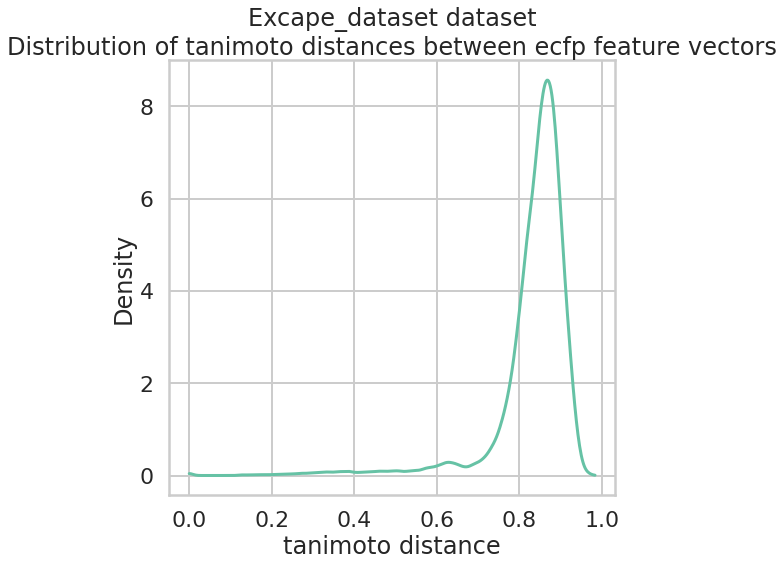

In [99]:
dp.plot_tani_dist_distr(excape, 'base_rdkit_smiles', 'Excape_dataset')

In [100]:
excape.columns


Index(['Ambit_InchiKey', 'Original_Entry_ID', 'Entrez_ID', 'Activity_Flag',
       'pXC50', 'DB', 'Original_Assay_ID', 'Tax_ID', 'Gene_Symbol',
       'Ortholog_Group', 'SMILES', 'base_rdkit_smiles'],
      dtype='object')

Computing fingerprints...
Done
Computing Tanimoto distance matrix...
Done


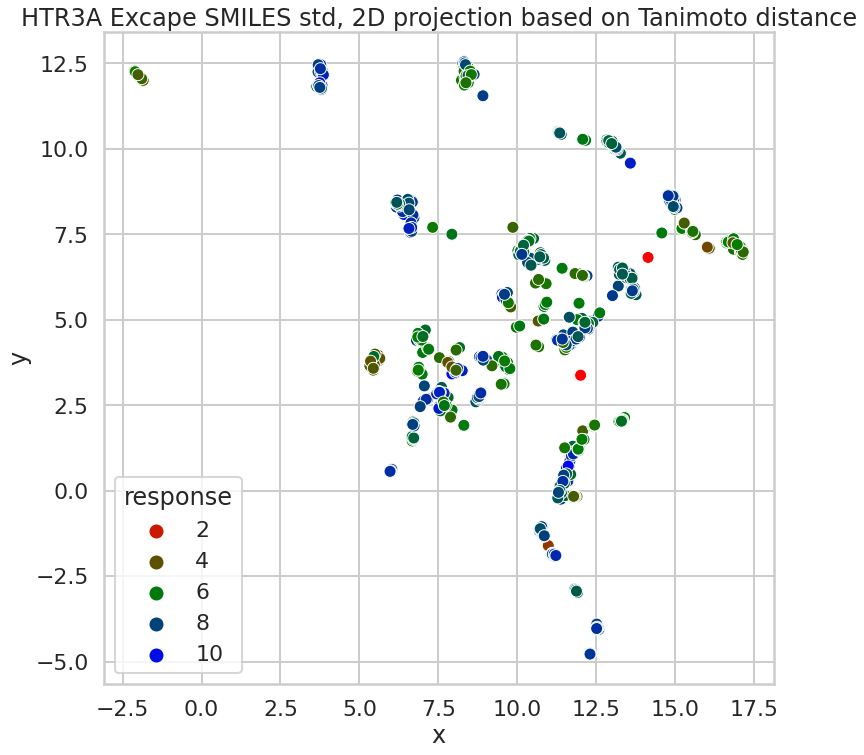

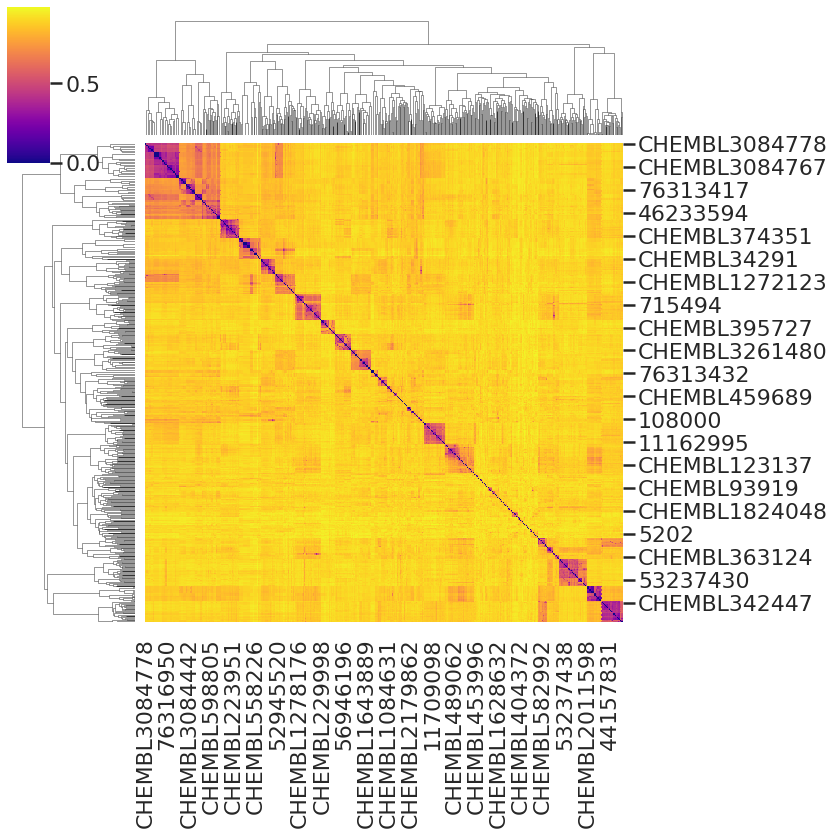

In [101]:
dp.diversity_plots('/content/drive/MyDrive/AMPL_EDA_07/HTR3A_Excape_SMILES_std.csv',
                   datastore=False, 
                   id_col ='Original_Entry_ID', 
                   smiles_col = 'base_rdkit_smiles', 
                   is_base_smiles=True, 
                   response_col = 'pXC50')

## Discussion on the analysis of the heatmap and density plots
```
what are Morgan fingerprints (ecfp)? 
what does radius mean?
what does a bit in an ECFP vector correspond to?
what radius and vector length are used in these functions?
hint: look at the .py files for more info
```
ECFP fingerprints are a bit vector representation of a compound's structure. Each bit represents the presence or absence of a certain 'connectivity' between atoms in a molecule. The radius used in the diversity plots function is radius 4 and length 1024. The tanimoto plot function uses radius 2. Radius means number of atoms you travel away from the given atom to assess connectivity, allowing you to look at larger or smaller molecule fragments.


```
what is tanimoto distance? What do values closer to zero or closer to one mean?
Do you think your sets of compounds are diverse?
What do you observe from the 2D projection of compounds?
Are there any similarities between groups of compounds in your datasets?
```

Tanimoto similarity (or jaccard index) represents how well two bit vectors overlap. Thus, distance represents how 'far' away they are from perfect overlap. A distance closer 1 means the fingerprints (and therefore molecules) are less similar to each other. A distance closer to zero means molecules are more similar. 

Compounds that are shown in this exercise have average tanimoto distances ~ 0.85 - 0.9, so they are fairly diverse.

In the ChEMBL dataset, the 2D project separates high and low pChEMBL values very well. The DTC and Excape datasets don't separate as well, but DTC also is on a very different scale.

From the heatmap, we can see clusters/squares of compounds with tanimoto distance closer to zero (purple) so I suspect there are some groups of compounds that are very similar.


# EDA: Curated data
- First let us curate the data
- Examine new compound overlaps
- Examine final response column distributions
- Filter for 
  - large compounds
  - too high / too low pXC50 values
- double check for no NA values left
- save final curated dataset for further processing

Start here if you want to restart from here. Dont forget to uncomment the following code chunk

In [102]:
# chembl=pd.read_csv("/content/drive/MyDrive/AMPL_EDA_07/HTR3A_ChEMBL_SMILES_std.csv", index_col=0)
# dtc=pd.read_csv("/content/drive/MyDrive/AMPL_EDA_07/HTR3A_DTC_SMILES_std.csv", index_col=0)
# excape=pd.read_csv("/content/drive/MyDrive/AMPL_EDA_07/HTR3A_Excape_SMILES_std.csv", index_col=0)

In [103]:
# rescue NA pChemblValues
chembl['pChEMBL_Value_nM'] = -np.log10(chembl.Standard_Value_nM/1000000000)


In [104]:
chembl.head(3)

,Molecule_ChEMBL_ID,Molecule_Name,Molecule_Max_Phase,Molecular_Weight,#RO5_Violations,AlogP,Compound_Key,Smiles,Standard_Type,Standard_Relation,Standard_Value,Standard_Units,pChEMBL_Value,Data_Validity_Comment,Comment,Uo_Units,Ligand_Efficiency_BEI,Ligand_Efficiency_LE,Ligand_Efficiency_LLE,Ligand_Efficiency_SEI,Potential_Duplicate,Assay_ChEMBL_ID,Assay_Description,Assay_Type,BAO_Format_ID,BAO_Label,Assay_Organism,Assay_Tissue_ChEMBL_ID,Assay_Tissue_Name,Assay_Cell_Type,Assay_Subcellular_Fraction,Assay_Parameters,Assay_Variant_Accession,Assay_Variant_Mutation,Target_ChEMBL_ID,Target_Name,Target_Organism,Target_Type,Document_ChEMBL_ID,Source_ID,Source_Description,Document_Journal,Document_Year,Cell_ChEMBL_ID,Properties,Standard_Value_nM,base_rdkit_smiles,pChEMBL_Value_nM
0,CHEMBL3233676,NaN,0.0,622.85,2.0,6.84,22a,CC1(C)C(=O)N(Cc2ccc(Cl)cc2Cl)C(=O)N1CCCCCN1CCN...,Inhibition,'=',13.75,%,NaN,NaN,NaN,UO_0000187,NaN,NaN,NaN,NaN,False,CHEMBL3240658,Reversible inhibition of human 5-HT3A expresse...,B,BAO_0000219,cell-based format,Homo sapiens,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CHEMBL1899,Serotonin 3a (5-HT3a) receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL3232706,1,Scientific Literature,Eur. J. Med. Chem.,2014.0,NaN,NaN,13.75,CC1(C)C(=O)N(Cc2ccc(Cl)cc2Cl)C(=O)N1CCCCCN1CCN...,7.861697
1,CHEMBL773,GLYCINE,4.0,75.07,0.0,-0.97,glycine,NCC(=O)O,EC50,NaN,NaN,NaN,NaN,NaN,Not Determined,NaN,NaN,NaN,NaN,NaN,False,CHEMBL896288,Antagonist activity at human 5HT3A receptor ex...,F,BAO_0000219,cell-based format,Homo sapiens,NaN,NaN,HEK293,NaN,NaN,NaN,NaN,CHEMBL1899,Serotonin 3a (5-HT3a) receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL1148788,1,Scientific Literature,J. Med. Chem.,2007.0,CHEMBL3307715,NaN,NaN,NCC(=O)O,NaN
2,CHEMBL3261486,NaN,0.0,312.37,0.0,0.88,9,O=C1c2cccc3[nH]c(=O)n(c23)CCN1[C@@H]1CN2CCC1CC2,Activity,'=',83.00,%,NaN,NaN,NaN,UO_0000187,NaN,NaN,NaN,NaN,False,CHEMBL3268498,Partial agonist activity at human 5-HT3A recep...,B,BAO_0000219,cell-based format,Homo sapiens,NaN,NaN,HEK293,NaN,NaN,NaN,NaN,CHEMBL1899,Serotonin 3a (5-HT3a) receptor,Homo sapiens,SINGLE PROTEIN,CHEMBL3259590,1,Scientific Literature,Bioorg. Med. Chem. Lett.,2014.0,CHEMBL3307715,NaN,83.00,O=C1c2cccc3[nH]c(=O)n(c23)CCN1[C@@H]1CN2CCC1CC2,7.080922


In [105]:
chembl.Standard_Type.unique()

array(['Inhibition', 'EC50', 'Activity', 'IC50', 'Ki', 'Vmax',
       '% Inhibition of Control Specific Binding (Mean n=2)', 'Ka',
       'pIC50', 'Emax', 'Kd', 'pKi', 'Kb', 'Selectivity ratio',
       'Efficacy', '% Ctrl'], dtype=object)

In [106]:
# select pIC50 values
vals = ['EC50', 'IC50', 'pIC50']
print(chembl.shape)
chembl=chembl[chembl.Standard_Type.isin(vals)]
print(chembl.shape)

(1949, 48)
(602, 48)


In [107]:
# drop NA pIC50's & smiles
chembl=chembl.dropna(axis=0, subset = ['pChEMBL_Value_nM','base_rdkit_smiles'])
print(chembl.shape)

(594, 48)


In [108]:
# note weird punctuation
chembl.Standard_Relation.unique()

array(["'='", "'>'", "'<'"], dtype=object)

In [109]:
# flip arrows and fix punctuation for relation column to reflect pValues not normal values
chembl['pRelation'] = chembl.Standard_Relation
chembl['pRelation'] = np.where(chembl.Standard_Relation == "'<'", ">", chembl.pRelation)
chembl['pRelation'] = np.where(chembl.Standard_Relation == "'>'", "<", chembl.pRelation)
chembl['pRelation'] = np.where(chembl.Standard_Relation == "'='", "=", chembl.pRelation)
chembl[['Standard_Relation', 'pRelation']].head()

,Standard_Relation,pRelation
3,'=',=
4,'>',<
5,'=',=
6,'>',<
7,'>',<


In [110]:
thresh=-np.log10(100/1000000000) # pIC50 of 100nM for threshold

In [111]:
print(chembl.shape)
chembl_cur = curate_data.aggregate_assay_data(chembl, value_col = 'pChEMBL_Value_nM', 
                                              output_value_col = 'pXC50',
                                              id_col = 'Molecule_ChEMBL_ID', 
                                              smiles_col = 'base_rdkit_smiles',
                                              relation_col = 'pRelation',
                                              active_thresh=thresh)
print(chembl_cur.shape)
chembl_cur.head()

(594, 49)
0 entries in input table are missing SMILES strings
517 unique SMILES strings are reduced to 517 unique base SMILES strings
(517, 5)


,compound_id,base_rdkit_smiles,relation,pXC50,active
0,CHEMBL141209,COC1Cc2ccccc2C2(CCN(Cc3ccccc3)CC2)O1,<,5.000000,0
1,CHEMBL572248,COc1cc(N)c(Cl)cc1C(=O)NCCN(C)C[C@@H]1CCCC[C@@]...,,5.602060,0
2,CHEMBL2087457,COc1ccc(-c2cc(NC(=O)CCCCN3CCCOCC3)[nH]n2)cc1,<,4.522879,0
3,CHEMBL3890437,CN1[C@@H]2COC[C@H]1C[C@@H](NC(=O)c1cn(-c3cccnc...,,9.125519,1
4,CHEMBL1277913,Nn1c(CCCCN2CCN(c3ccc4ccccc4n3)CC2)nc2cc(Cl)ccc...,<,7.000000,0


In [112]:
chembl_cur.to_csv("/content/drive/MyDrive/AMPL_EDA_07/HTR3A_ChEMBL_cur.csv")

In [113]:
# DTC
# select pIC50 values
vals = ['EC50', 'IC50', 'PIC50']
print(dtc.shape)
dtc=dtc[dtc.End_Point_Standard_Type.isin(vals)]
print(dtc.shape)

# flip arrows for relation column to reflect pValues not normal values
dtc['pRelation'] = dtc.End_Point_Standard_Relation
dtc['pRelation'] = np.where(dtc.End_Point_Standard_Relation == "<", ">", dtc.pRelation)
dtc['pRelation'] = np.where(dtc.End_Point_Standard_Relation == ">", "<", dtc.pRelation)
dtc['pRelation'] = np.where(dtc.End_Point_Standard_Relation == "=", "=", dtc.pRelation)
print(dtc.pRelation.unique())
display(dtc[['End_Point_Standard_Relation', 'pRelation']].head())

dtc=dtc.dropna(axis=0, subset = ['pDTC_Value','base_rdkit_smiles'])
print(dtc.shape)

# aggregate duplicates
dtc_cur = curate_data.aggregate_assay_data(dtc, value_col = 'pDTC_Value', 
                                              output_value_col = 'pXC50',
                                              id_col = 'Compound_ID', 
                                              smiles_col = 'base_rdkit_smiles',
                                              relation_col = 'pRelation',
                                              active_thresh=thresh)
dtc_cur.to_csv("/content/drive/MyDrive/AMPL_EDA_07/HTR3A_DTC_cur.csv")
print(dtc_cur.shape)
print(dtc_cur.relation.unique())
dtc_cur.head()

(1305, 46)
(275, 46)
['<' '=' nan '>']


,End_Point_Standard_Relation,pRelation
0,>,<
4,>,<
5,>,<
6,>,<
7,>,<


(267, 47)
0 entries in input table are missing SMILES strings
226 unique SMILES strings are reduced to 226 unique base SMILES strings
(226, 5)
['<' '' '>']


,compound_id,base_rdkit_smiles,relation,pXC50,active
0,CHEMBL141209,COC1Cc2ccccc2C2(CCN(Cc3ccccc3)CC2)O1,<,5.000000,0
1,CHEMBL2180836,COc1ccc(-c2cc(NC(=O)CCCN3CCCCCC3)n[nH]2)cc1,<,4.500000,0
2,CHEMBL225543,O=C(NCCN1CCCCC1)c1ccc2c(=O)n(C3CCCCC3)c(=O)[nH...,,5.698970,0
3,CHEMBL39,NCCc1c[nH]c2ccc(O)cc12,,6.560347,0
4,CHEMBL1277558,CC(=O)N1CCc2c(sc3nc(SCCCN4CCN(c5ccc6ccccc6n5)C...,,7.110138,1


In [114]:
# excape: has no relation col, so create one with all ''
excape['pRelation']=''
print(excape.shape)
print(excape.pRelation.unique())
excape=excape.dropna(axis=0, subset = ['pXC50','base_rdkit_smiles'])
print(excape.shape)
# aggregate duplicates
excape_cur = curate_data.aggregate_assay_data(excape, value_col = 'pXC50', 
                                              output_value_col = 'pXC50',
                                              id_col = 'Original_Entry_ID', 
                                              smiles_col = 'base_rdkit_smiles',
                                              relation_col = 'pRelation',
                                              active_thresh=thresh)
excape_cur.to_csv("/content/drive/MyDrive/AMPL_EDA_07/HTR3A_Excape_cur.csv")
print(excape_cur.shape)
print(excape_cur.relation.unique())
excape_cur.head()

(649, 13)
['']
(645, 13)
0 entries in input table are missing SMILES strings
601 unique SMILES strings are reduced to 600 unique base SMILES strings
(600, 5)
['']


,compound_id,base_rdkit_smiles,relation,pXC50,active
0,45485619,COc1cc(N)c(Cl)cc1C(=O)NCCN(C)C[C@@H]1CCCC[C@@]...,,5.60206,0
1,CHEMBL388049,COc1ccc(C[N+]23CC[C@H]4[C@@H]2C[C@H](C2=CN5c6c...,,4.52000,0
2,CHEMBL2448165,COc1cc(N)c(Cl)cc1C(=O)N[C@@H]1C2CC3CN(C2)CC31,,8.92000,1
3,72698087,Fc1cccc2c1nc(OCC1CCN(CCC(F)(F)F)CC1)c1cccnc12,,5.92082,0
4,CHEMBL225485,CCC1CCCCN1CCNC(=O)c1ccc2c(=O)n(Cc3ccc(Cl)cc3)c...,,4.87000,0


In [115]:
chembl_cur['datasource'] = 'chembl'
dtc_cur['datasource']='dtc'
excape_cur['datasource']='excape'
HTR3A = pd.concat([chembl_cur, dtc_cur, excape_cur])
HTR3A.to_csv("/content/drive/MyDrive/AMPL_EDA_07/HTR3A_merge.csv")
print(HTR3A.shape)

(1343, 6)


In [116]:
import importlib
importlib.reload(curate_data)
HTR3A_cur = curate_data.aggregate_assay_data(HTR3A, value_col = 'pXC50', 
                                              id_col = 'compound_id', 
                                              smiles_col = 'base_rdkit_smiles',
                                              relation_col = 'relation',
                                              active_thresh=thresh)

print(HTR3A_cur.shape)
print(HTR3A.relation.unique())
HTR3A_cur.head()

0 entries in input table are missing SMILES strings
1041 unique SMILES strings are reduced to 1041 unique base SMILES strings
(1041, 5)
['<' '' '>']


,compound_id,base_rdkit_smiles,relation,pXC50,active
0,CHEMBL141209,COC1Cc2ccccc2C2(CCN(Cc3ccccc3)CC2)O1,<,5.000000,0
1,45485619,COc1cc(N)c(Cl)cc1C(=O)NCCN(C)C[C@@H]1CCCC[C@@]...,,5.602060,0
2,CHEMBL2087457,COc1ccc(-c2cc(NC(=O)CCCCN3CCCOCC3)[nH]n2)cc1,<,4.522879,0
3,CHEMBL388049,COc1ccc(C[N+]23CC[C@H]4[C@@H]2C[C@H](C2=CN5c6c...,,4.520000,0
4,CHEMBL3890437,CN1[C@@H]2COC[C@H]1C[C@@H](NC(=O)c1cn(-c3cccnc...,,9.125519,1


In [117]:
HTR3A_cur.relation.unique()

array(['<', ''], dtype=object)

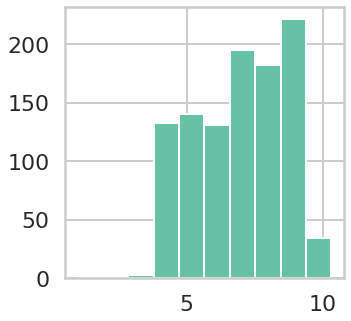

In [118]:
HTR3A_cur.pXC50.hist(figsize=(5,5));

In [119]:
HTR3A_cur.active.sum()

552

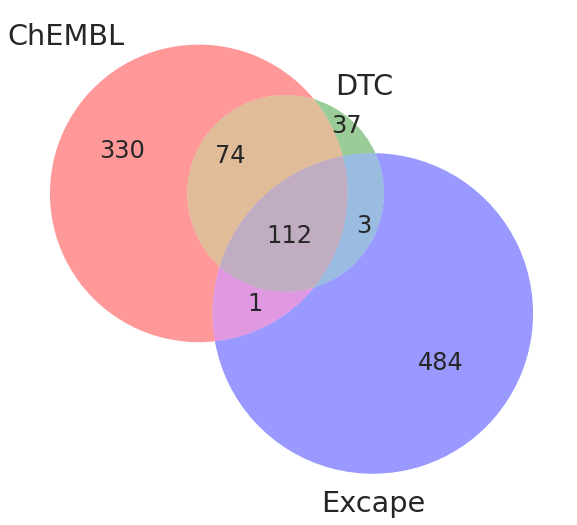

In [120]:
mpv.venn3([set(HTR3A.loc[HTR3A.datasource=='chembl','base_rdkit_smiles']),
           set(HTR3A.loc[HTR3A.datasource=='dtc','base_rdkit_smiles']),
           set(HTR3A.loc[HTR3A.datasource=='excape','base_rdkit_smiles']),],
          set_labels = ['ChEMBL','DTC','Excape']);

In [121]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.DataManip.Metric.rdMetricMatrixCalc import GetTanimotoDistMat

import umap
from scipy.stats.kde import gaussian_kde
from scipy.cluster.hierarchy import linkage


2021-09-17 21:50:35,143 *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


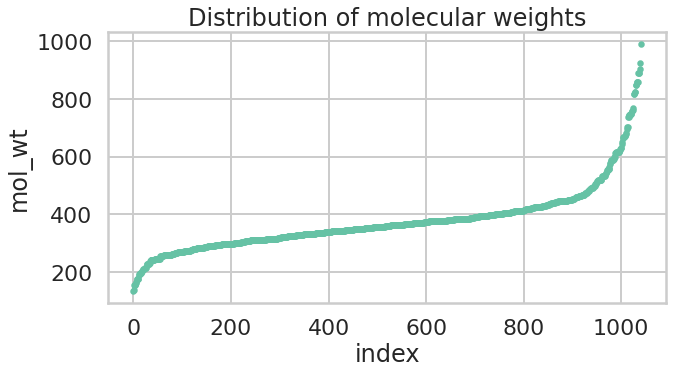

In [122]:
HTR3A_cur["mol_wt"] = [Chem.Descriptors.ExactMolWt(Chem.MolFromSmiles(smile)) for smile in HTR3A_cur["base_rdkit_smiles"]]
HTR3A_cur = HTR3A_cur.sort_values('mol_wt')
HTR3A_cur=HTR3A_cur.reset_index(drop=True)
HTR3A_cur=HTR3A_cur.reset_index() # plot x axis as index #'s
fig,ax=plt.subplots(figsize=(10,5))
HTR3A_cur.plot(kind='scatter', x='index', y='mol_wt', ax=ax);
plt.title("Distribution of molecular weights");

In [123]:
print(HTR3A_cur.shape)
HTR3A_cur = HTR3A_cur[HTR3A_cur.mol_wt <1400]
print(HTR3A_cur.shape)

(1041, 7)
(1041, 7)


2021-09-17 21:50:35,636 *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


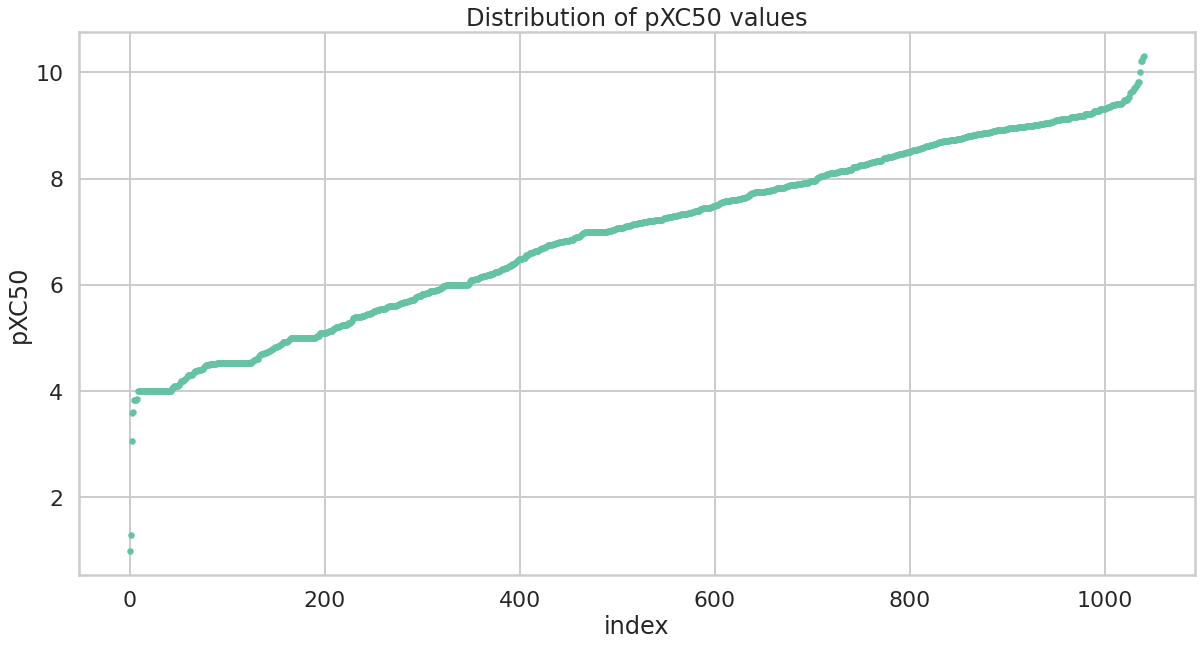

In [124]:
HTR3A_cur=HTR3A_cur.drop(columns=['index'])
HTR3A_cur = HTR3A_cur.sort_values('pXC50')
HTR3A_cur = HTR3A_cur.reset_index(drop=True)
HTR3A_cur = HTR3A_cur.reset_index() # plot x axis as index #'s
fig,ax=plt.subplots(figsize=(20,10))
HTR3A_cur.plot(kind='scatter', x='index', y='pXC50', ax=ax);
plt.title("Distribution of pXC50 values");

In [125]:
print(HTR3A_cur.shape)
HTR3A_cur=HTR3A_cur[HTR3A_cur.pXC50>2]
HTR3A_cur=HTR3A_cur[HTR3A_cur.pXC50<14]
print(HTR3A_cur.shape)

(1041, 7)
(1039, 7)


In [126]:
for col in HTR3A_cur.columns:
  print(col, HTR3A_cur[col].isna().values.any())

index False
compound_id True
base_rdkit_smiles False
relation False
pXC50 False
active False
mol_wt False


array([0.94444444, 0.88888889, 0.94642857, ..., 0.83950617, 0.83950617,
       0.85294118])

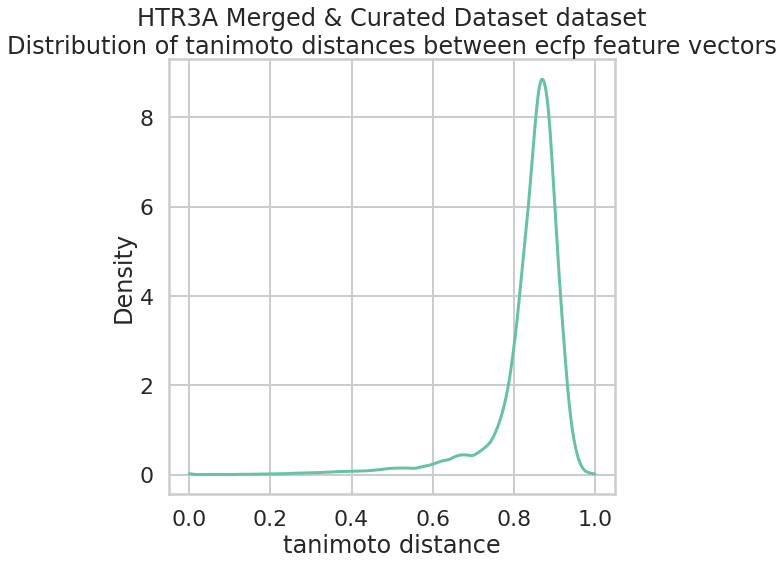

In [127]:
dp.plot_tani_dist_distr(HTR3A_cur, 'base_rdkit_smiles', 'HTR3A Merged & Curated Dataset')

In [128]:
HTR3A_cur.to_csv("/content/drive/MyDrive/AMPL_EDA_07/HTR3A_cur.csv")

Computing fingerprints...
Done
Computing Tanimoto distance matrix...
Done


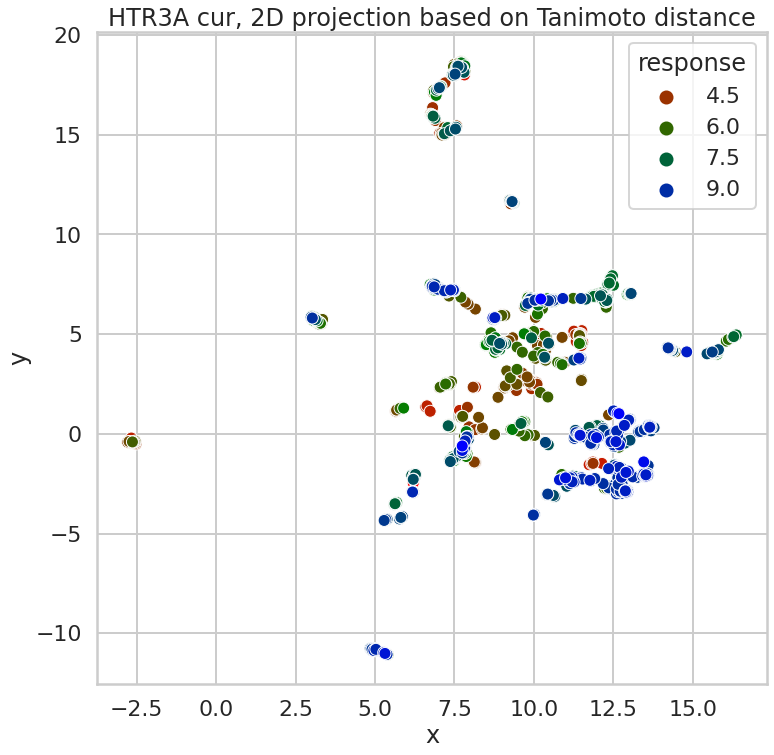

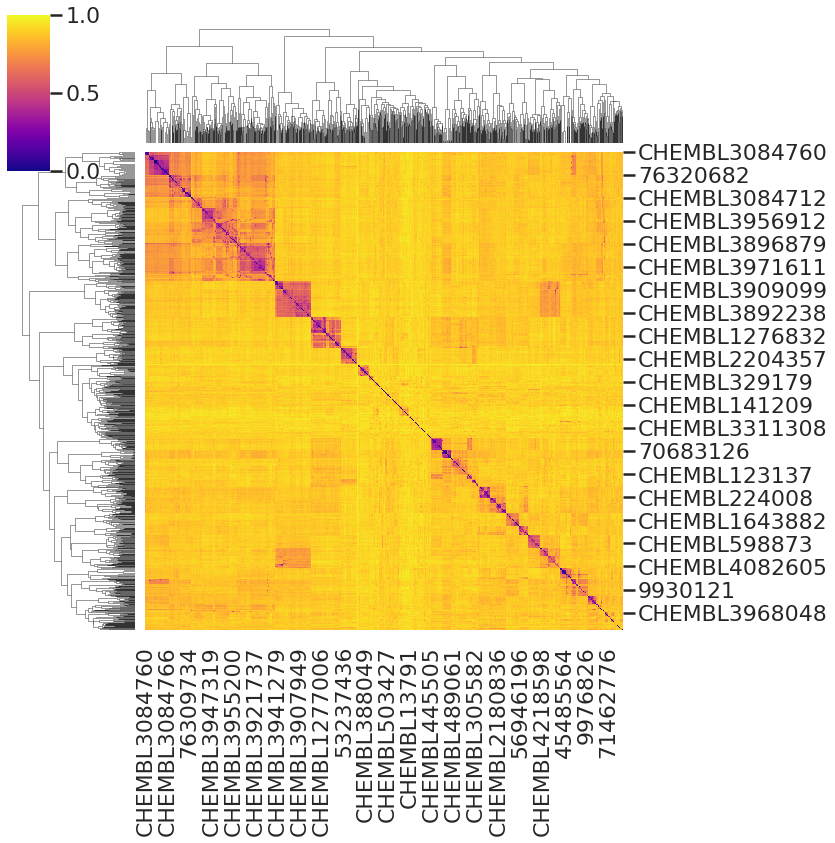

In [129]:
dp.diversity_plots('/content/drive/MyDrive/AMPL_EDA_07/HTR3A_cur.csv', 
                   datastore = False,
                   id_col ='compound_id', 
                   smiles_col = 'base_rdkit_smiles', 
                   is_base_smiles=True, 
                   response_col = 'pXC50')

Computing fingerprints...
Done
Computing Tanimoto distance matrix...
Done


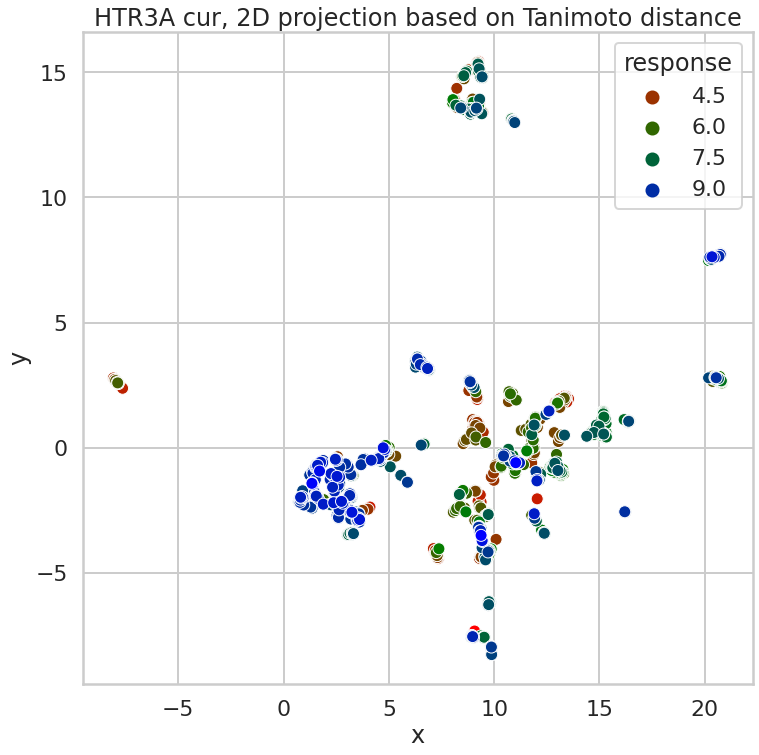

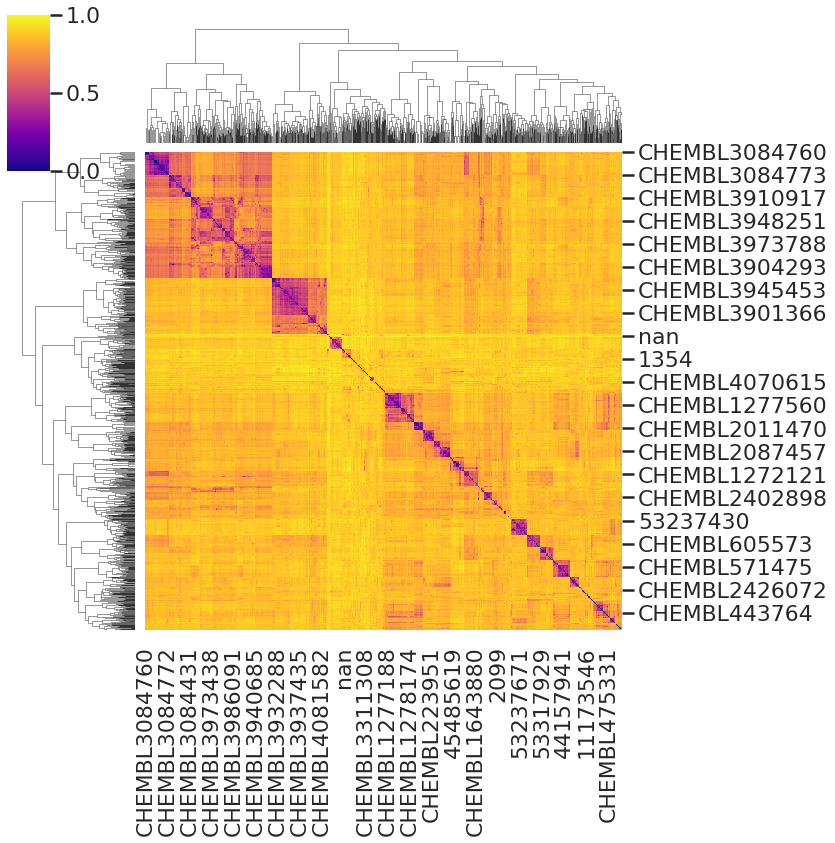

In [130]:
dp.diversity_plots('/content/drive/MyDrive/AMPL_EDA_07/HTR3A_cur.csv', 
                   datastore = False,
                   id_col ='compound_id', 
                   smiles_col = 'base_rdkit_smiles', 
                   is_base_smiles=True, 
                   response_col = 'pXC50',
                   ecfp_radius = 2)

Computing fingerprints...
Done
Computing Tanimoto distance matrix...
Done


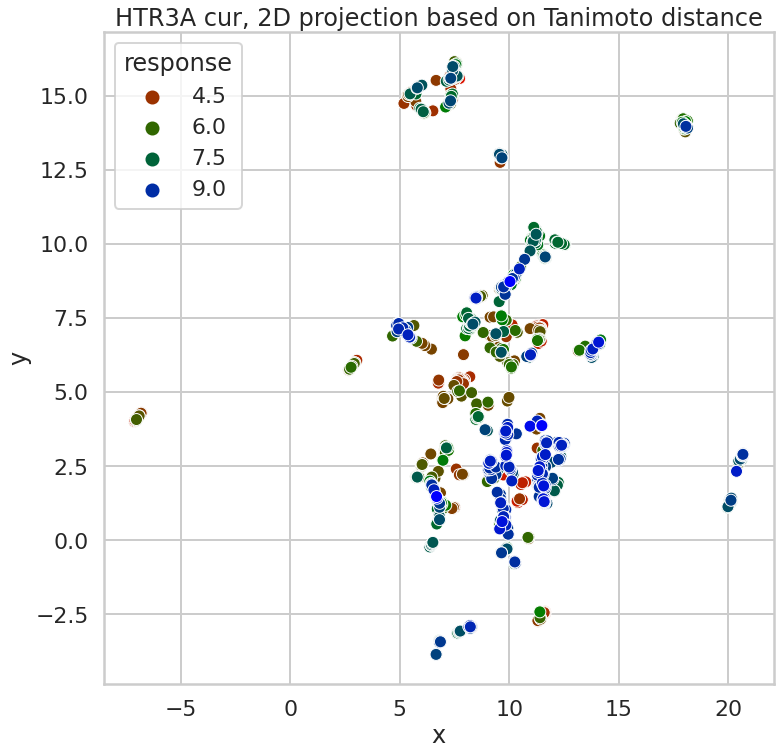

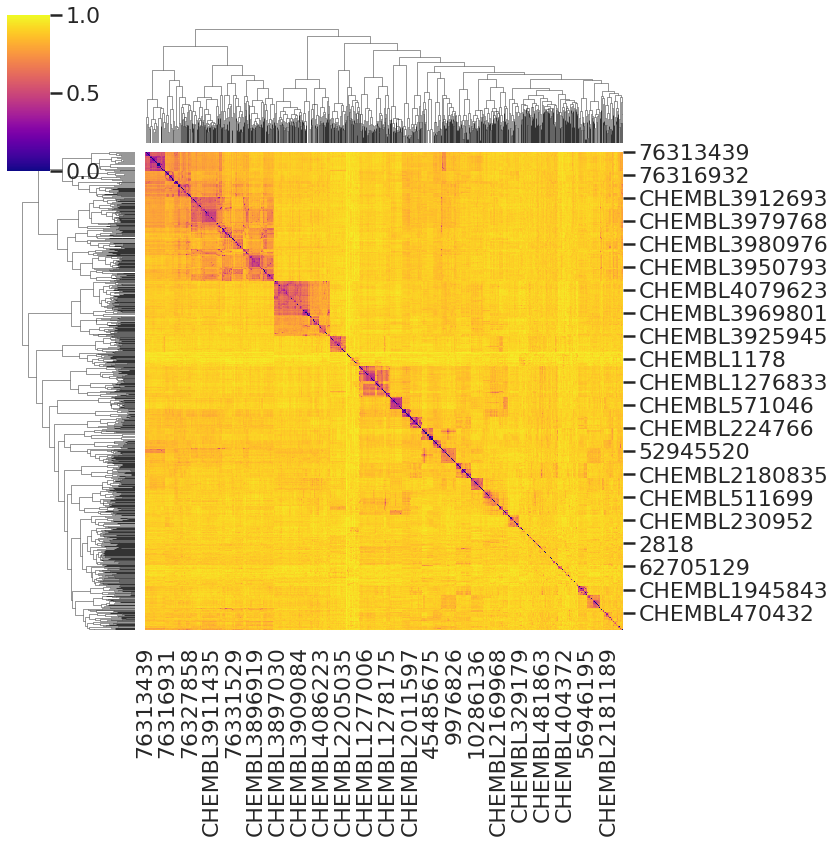

In [131]:
dp.diversity_plots('/content/drive/MyDrive/AMPL_EDA_07/HTR3A_cur.csv', 
                   datastore = False,
                   id_col ='compound_id', 
                   smiles_col = 'base_rdkit_smiles', 
                   is_base_smiles=True, 
                   response_col = 'pXC50',
                   ecfp_radius = 6)

The following code takes too long. Try only when you are running this
on a dedicated server

In [132]:
# warning: max_for_mcs = 1100, takes too long on COLAB
importlib.reload(dp)
# dp.diversity_plots('/content/drive/MyDrive/AMPL_EDA_07/HTR3A_cur.csv', 
#                    id_col ='compound_id', smiles_col = 'base_rdkit_smiles', 
#                    is_base_smiles=True, response_col = 'pXC50', 
#                    max_for_mcs=1100)

<module 'atomsci.ddm.pipeline.diversity_plots' from '/usr/local/lib/python3.7/dist-packages/atomsci/ddm/pipeline/diversity_plots.py'>

# Now you're ready to move on to the next stage of EDA & modeling: featurizing datasets
- featurize with structure-based fingerprints like ECFP
- or molecular descriptor sets like RDKit and Mordred
- these are high - dimensional datasets (200-2000 features or 'dimensions')
- so UMAP, tSNE and other dimensionality reduction techniques will help visualize the 'chemical space' of the dataset

In [133]:
!date

Fri Sep 17 21:51:12 UTC 2021
